 # Voxel Allegiance Analysis



 Explores three approaches to quantifying voxel-level category reorganization in VOTC:

 1. **Winner-take-all maps** — each voxel colored by its preferred category

 2. **Transition matrices** — which categories trade territory T1→T2

 3. **Profile stability** — cosine similarity of voxel response vectors across time



 Also computes Blauch-style summed selectivity per category per hemisphere.



 COPEs used:

 - Raw betas: face=15, house=16, object=17, word=18

 - Category vs all: face=6, house=7, object=8, word=9

 - Differential: face=1(>obj), house=2(>obj), object=3(>scr), word=4(>obj)

In [2]:
import gc
gc.collect()

479

In [3]:
import os
import sys
import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from scipy.spatial.distance import cosine
from scipy.stats import pearsonr
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import (processed_dir, skip_subs, get_sessions,
                           is_patient, get_sub_info, _load_csv)


 ## Configuration

In [4]:
# ── Category definitions ──────────────────────────────────────────────────────

CATEGORIES = ['face', 'house', 'object', 'word']
CAT_COLORS = {
    'face':   '#E74C3C',   # red
    'house':  '#3498DB',   # blue
    'object': '#2ECC71',   # green
    'word':   '#F39C12',   # orange
    'none':   '#BDC3C7',   # gray (subthreshold)
}

# ── Cope maps ─────────────────────────────────────────────────────────────────
RAW_BETA_COPES = {'face': 15, 'house': 16, 'object': 17, 'word': 18}
CAT_VS_ALL_COPES = {'face': 6, 'house': 7, 'object': 8, 'word': 9}
DIFFERENTIAL_COPES = {'face': 1, 'house': 2, 'object': 3, 'word': 4}

# ── Which cope set to use for allegiance ──────────────────────────────────────
ALLEGIANCE_COPE_SET = 'cat_vs_all'   # <-- CHANGE THIS to try different approaches

# ── Thresholds ────────────────────────────────────────────────────────────────
WTA_THRESHOLD = 0

# ── Pre-surgery sessions to skip ──────────────────────────────────────────────
PRE_SURGERY_SESSIONS = {
    'sub-021': ['01'], 'sub-045': ['01'], 'sub-047': ['01'], 'sub-049': ['01'],
    'sub-070': ['01'], 'sub-073': ['01'], 'sub-081': ['01'], 'sub-086': ['01'],
}

# ── Exclusions ────────────────────────────────────────────────────────────────
EXCLUDE_SUBS = ['OTC108', 'control083', 'control085', 'OTC017', 'control027']



 ## Helper Functions

In [5]:
def get_cope_map():
    """Return the cope mapping for the chosen allegiance set."""
    if ALLEGIANCE_COPE_SET == 'raw_beta':
        return RAW_BETA_COPES
    elif ALLEGIANCE_COPE_SET == 'cat_vs_all':
        return CAT_VS_ALL_COPES
    elif ALLEGIANCE_COPE_SET == 'differential':
        return DIFFERENTIAL_COPES
    else:
        raise ValueError(f"Unknown cope set: {ALLEGIANCE_COPE_SET}")


def load_subjects():
    """Load subject info, return dict keyed by sub ID."""
    df = _load_csv()
    subjects = {}
    for sub_clean in sorted(df['sub_clean'].unique()):
        if sub_clean in skip_subs:
            continue
        sid = f'sub-{sub_clean}'
        sessions = get_sessions(sub_clean)
        base = os.path.join(processed_dir, sid)
        if not sessions or not os.path.exists(base):
            continue
        info = get_sub_info(sub_clean, sessions[0])
        pt = is_patient(sub_clean)
        intact = info.get('intact_hemi', '')
        code = f"{info.get('group', '')}{sub_clean}"
        if code in EXCLUDE_SUBS:
            continue

        # Actual first session — always the true first (e.g. ses-01)
        # Used for ROI paths and cope filename suffixes
        actual_first_ses = f'{sessions[0]:02d}'

        # Filter sessions: remove pre-surgical for analysis
        post_sessions = []
        for s in sessions:
            ses_str = f'{s:02d}'
            if sid in PRE_SURGERY_SESSIONS and ses_str in PRE_SURGERY_SESSIONS[sid]:
                continue
            post_sessions.append(ses_str)

        if not post_sessions:
            continue

        subjects[sid] = {
            'code': code,
            'sessions': post_sessions,
            'actual_first_ses': actual_first_ses,
            'hemi': ('l' if intact == 'left' else 'r') if pt else None,
            'group': info.get('group', 'unknown'),
            #'patient_status': 'patient' if pt else 'control',
            'patient_status': info.get('group', 'unknown'),
            'intact_hemi': intact,
            'surgery_side': ('right' if intact == 'left' else 'left') if pt else 'na',
        }
    return subjects


def get_votc_mask(sub_id, actual_first_ses, hemi):
    """
    Get a broad VOTC mask by combining all 4 category searchmasks.
    Uses actual_first_ses (always ses-01) since searchmasks are anatomical.
    """
    roi_dir = os.path.join(processed_dir, sub_id, f'ses-{actual_first_ses}', 'ROIs')

    combined = None
    affine = None
    for cat in CATEGORIES:
        mask_path = os.path.join(roi_dir, f'{hemi}_{cat}_searchmask.nii.gz')
        if os.path.exists(mask_path):
            img = nib.load(mask_path)
            data = img.get_fdata() > 0
            if combined is None:
                combined = data.copy()
                affine = img.affine
            else:
                combined = combined | data

    if combined is None:
        ventral_dir = os.path.join(processed_dir, sub_id, f'ses-{actual_first_ses}',
                                    'derivatives', 'rois')
        ventral_path = os.path.join(ventral_dir, f'{hemi}Ventral.nii.gz')
        if os.path.exists(ventral_path):
            img = nib.load(ventral_path)
            combined = img.get_fdata() > 0
            affine = img.affine

    return combined, affine


def load_category_betas(sub_id, session, actual_first_ses, mask, cope_map):
    """
    Load beta/zstat values for all 4 categories within a mask.

    actual_first_ses: the true first session (e.g. '01'), used for
      cope filename suffix (cope1_ses01.nii.gz). Not filtered by pre-surgery.
    """
    feat_dir = os.path.join(processed_dir, sub_id, f'ses-{session}',
                            'derivatives', 'fsl', 'loc', 'HighLevel.gfeat')

    if ALLEGIANCE_COPE_SET == 'raw_beta':
        stat_file = 'cope1.nii.gz' if session == actual_first_ses else f'cope1_ses{actual_first_ses}.nii.gz'
    else:
        stat_file = 'zstat1.nii.gz' if session == actual_first_ses else f'zstat1_ses{actual_first_ses}.nii.gz'

    betas = {}
    for cat, cope_num in cope_map.items():
        fpath = os.path.join(feat_dir, f'cope{cope_num}.feat', 'stats', stat_file)
        if not os.path.exists(fpath):
            return None
        img = nib.load(fpath)
        data = img.get_fdata()
        betas[cat] = data[mask]

    return betas



 ## Load All Data

In [6]:
print("Loading subjects...")
subjects = load_subjects()
print(f"  {len(subjects)} subjects loaded")

# Check sub-017 excluded
print(f"  sub-017 in subjects? {'sub-017' in subjects}")

# Identify longitudinal subjects (2+ post-surgical sessions)
long_subs = {sid: info for sid, info in subjects.items()
             if len(info['sessions']) >= 2}
print(f"  {len(long_subs)} longitudinal subjects")

ctrl_long = {s: i for s, i in long_subs.items() if i['patient_status'] == 'control'}
pt_long = {s: i for s, i in long_subs.items() if i['patient_status'] == 'OTC'}
print(f"    Controls: {len(ctrl_long)}, Patients: {len(pt_long)}")

# List patients with resection side
for s, i in pt_long.items():
    print(f"    {s}: surgery={i['surgery_side']}, intact={i['intact_hemi']}, "
          f"hemi={i['hemi']}, sessions={i['sessions']}, "
          f"actual_first={i['actual_first_ses']}")

# Cross-sectional
ctrl_all = {s: i for s, i in subjects.items() if i['patient_status'] == 'control'}
pt_all = {s: i for s, i in subjects.items() if i['patient_status'] == 'OTC'}
print(f"  Cross-sectional — Controls: {len(ctrl_all)}, Patients: {len(pt_all)}")



Loading subjects...
  46 subjects loaded
  sub-017 in subjects? False
  16 longitudinal subjects
    Controls: 8, Patients: 5
    sub-004: surgery=right, intact=left, hemi=l, sessions=['01', '02', '03', '05', '06'], actual_first=01
    sub-008: surgery=right, intact=left, hemi=l, sessions=['01', '02'], actual_first=01
    sub-010: surgery=left, intact=right, hemi=r, sessions=['02', '03'], actual_first=02
    sub-021: surgery=left, intact=right, hemi=r, sessions=['02', '03'], actual_first=01
    sub-079: surgery=left, intact=right, hemi=r, sessions=['01', '02'], actual_first=01
  Cross-sectional — Controls: 21, Patients: 16


 ## 1. Winner-Take-All Maps

In [7]:
def compute_wta(betas, threshold=0):
    """
    Winner-take-all assignment for each voxel.
    Returns: winners (0-3 or -1), margin (1st-2nd), max_vals
    """
    n_voxels = len(betas[CATEGORIES[0]])
    beta_matrix = np.column_stack([betas[cat] for cat in CATEGORIES])

    max_vals = np.max(beta_matrix, axis=1)
    winners = np.argmax(beta_matrix, axis=1)

    sorted_betas = np.sort(beta_matrix, axis=1)
    margin = sorted_betas[:, -1] - sorted_betas[:, -2]

    if threshold > 0:
        winners[max_vals < threshold] = -1

    return winners, margin, max_vals


def wta_summary(winners):
    """Count voxels per category from WTA assignment."""
    total = len(winners)
    if total == 0:
        return {cat: 0 for cat in CATEGORIES + ['none']}, {cat: 0.0 for cat in CATEGORIES + ['none']}
    counts = {}
    for i, cat in enumerate(CATEGORIES):
        counts[cat] = int(np.sum(winners == i))
    counts['none'] = int(np.sum(winners == -1))
    pcts = {k: v / total * 100 for k, v in counts.items()}
    return counts, pcts



In [8]:
# ── Compute WTA for all subjects, first available session ─────────────────────

cope_map = get_cope_map()
threshold = WTA_THRESHOLD if ALLEGIANCE_COPE_SET == 'raw_beta' else 1.96

print(f"Cope set: {ALLEGIANCE_COPE_SET}")
print(f"Threshold: {threshold}")
print(f"Copes: {cope_map}")
print()

wta_results = {}
skipped = []

for sid, info in subjects.items():
    first_ses = info['sessions'][0]
    actual_first = info['actual_first_ses']
    hemi = info['hemi'] if info['patient_status'] == 'OTC' else 'l'
    hemis = ['l', 'r'] if info['patient_status'] == 'control' else [hemi]

    for h in hemis:
        mask, affine = get_votc_mask(sid, actual_first, h)
        if mask is None:
            print(f"  SKIP {sid} {h}: no mask found")
            skipped.append((sid, h, 'no_mask'))
            continue

        n_mask_voxels = int(mask.sum())
        if n_mask_voxels == 0:
            print(f"  SKIP {sid} {h}: empty mask (0 voxels)")
            skipped.append((sid, h, 'empty_mask'))
            continue

        betas = load_category_betas(sid, first_ses, actual_first, mask, cope_map)
        if betas is None:
            print(f"  SKIP {sid} ses-{first_ses} {h}: cope files not found")
            skipped.append((sid, h, 'no_copes'))
            continue

        n_beta_voxels = len(betas[CATEGORIES[0]])
        if n_beta_voxels == 0:
            print(f"  SKIP {sid} {h}: betas empty after masking")
            skipped.append((sid, h, 'empty_betas'))
            continue

        winners, margin, max_vals = compute_wta(betas, threshold)
        counts, pcts = wta_summary(winners)

        wta_results[(sid, first_ses, h)] = {
            'winners': winners,
            'margin': margin,
            'max_vals': max_vals,
            'counts': counts,
            'pcts': pcts,
            'n_voxels': len(winners),
            'group': info['patient_status'],
            'surgery_side': info.get('surgery_side', 'na'),
            'info': info,
        }

print(f"\nComputed WTA for {len(wta_results)} subject-hemisphere entries")
print(f"Skipped {len(skipped)} entries:")
for sid, h, reason in skipped:
    print(f"  {sid} {h}: {reason}")



Cope set: cat_vs_all
Threshold: 1.96
Copes: {'face': 6, 'house': 7, 'object': 8, 'word': 9}

  SKIP sub-090 ses-01 r: cope files not found

Computed WTA for 66 subject-hemisphere entries
Skipped 1 entries:
  sub-090 r: no_copes


In [9]:
# ── Summarize WTA territory ──────────────────────────────────────────────────

def summarize_group_wta(wta_results, group, hemi=None, surgery_side=None):
    """Average WTA percentages across subjects in a group."""
    pct_rows = []
    for (sid, ses, h), res in wta_results.items():
        if res['group'] != group:
            continue
        if hemi is not None and h != hemi:
            continue
        if surgery_side is not None and res.get('surgery_side', 'na') != surgery_side:
            continue
        pct_rows.append(res['pcts'])

    if not pct_rows:
        return None
    df = pd.DataFrame(pct_rows)
    return df.describe()

print("=== CONTROLS — LEFT HEMISPHERE ===")
s = summarize_group_wta(wta_results, 'control', 'l')
if s is not None: print(s.loc[['count', 'mean', 'std']].round(1))

print("\n=== CONTROLS — RIGHT HEMISPHERE ===")
s = summarize_group_wta(wta_results, 'control', 'r')
if s is not None: print(s.loc[['count', 'mean', 'std']].round(1))

print("\n=== PATIENTS — L-RESECTION (intact LH) ===")
s = summarize_group_wta(wta_results, 'OTC', 'l', surgery_side='right')
if s is not None: print(s.loc[['count', 'mean', 'std']].round(1))

print("\n=== PATIENTS — R-RESECTION (intact RH) ===")
s = summarize_group_wta(wta_results, 'OTC', 'r', surgery_side='left')
if s is not None: print(s.loc[['count', 'mean', 'std']].round(1))



=== CONTROLS — LEFT HEMISPHERE ===
       face  house  object  word  none
count  21.0   21.0    21.0  21.0  21.0
mean    7.5   16.5    24.0  12.5  39.5
std     4.6    7.5     8.8   7.0   9.8

=== CONTROLS — RIGHT HEMISPHERE ===
       face  house  object  word  none
count  21.0   21.0    21.0  21.0  21.0
mean   10.7   20.1    20.1   9.9  39.2
std     5.8    7.7     9.0   6.7   9.9

=== PATIENTS — L-RESECTION (intact LH) ===
       face  house  object  word  none
count   8.0    8.0     8.0   8.0   8.0
mean   10.6   14.6    13.5   9.9  51.4
std     6.9    5.0     5.4   8.3  14.0

=== PATIENTS — R-RESECTION (intact RH) ===
       face  house  object  word  none
count   7.0    7.0     7.0   7.0   7.0
mean   14.0   12.1    18.6  12.7  42.6
std     6.3    7.8     9.6  10.5  11.7


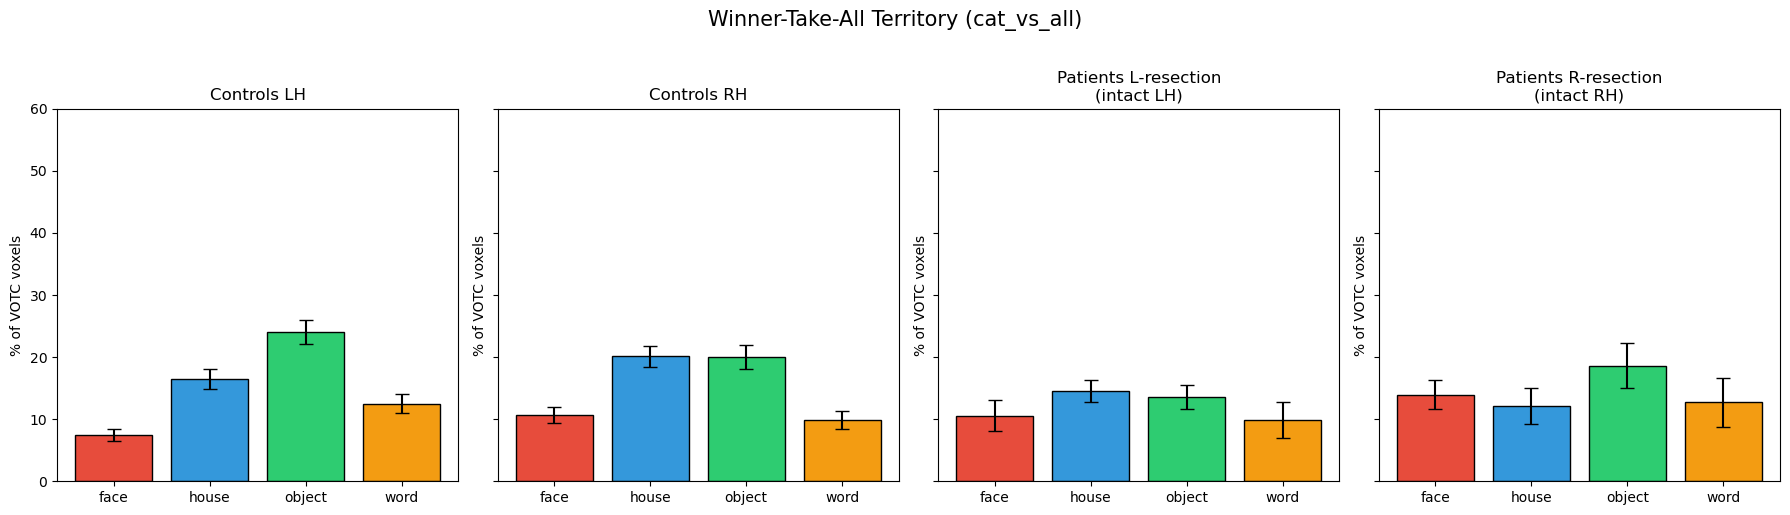

In [10]:
# ── Bar chart: Average territory per category ─────────────────────────────────

panels = [
    ('Controls LH', 'control', 'l', None),
    ('Controls RH', 'control', 'r', None),
    ('Patients L-resection\n(intact LH)', 'OTC', 'l', 'right'),
    ('Patients R-resection\n(intact RH)', 'OTC', 'r', 'left'),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)

for ax, (title, group, hemi, surg) in zip(axes, panels):
    pct_rows = []
    for (sid, ses, h), res in wta_results.items():
        if res['group'] != group:
            continue
        if hemi is not None and h != hemi:
            continue
        if surg is not None and res.get('surgery_side', 'na') != surg:
            continue
        pct_rows.append(res['pcts'])

    if not pct_rows:
        ax.set_title(f"{title}\n(no data)")
        continue

    df = pd.DataFrame(pct_rows)
    means = df[CATEGORIES].mean()
    sems = df[CATEGORIES].sem()

    bars = ax.bar(CATEGORIES, means, yerr=sems, capsize=5,
                  color=[CAT_COLORS[c] for c in CATEGORIES], edgecolor='black')
    ax.set_title(title, fontsize=12)
    ax.set_ylabel('% of VOTC voxels')
    ax.set_ylim(0, 60)

plt.suptitle(f'Winner-Take-All Territory ({ALLEGIANCE_COPE_SET})', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'group_results',
            f'wta_territory_{ALLEGIANCE_COPE_SET}.png'), dpi=150, bbox_inches='tight')
plt.show()



 ## 2. Longitudinal Transition Matrices

In [11]:
def compute_transition_matrix(winners_t1, winners_t2, n_categories=4):
    """
    Build transition matrix from T1 winners to T2 winners.
    Only includes voxels assigned to a category at BOTH timepoints.
    """
    valid = (winners_t1 >= 0) & (winners_t2 >= 0)
    w1 = winners_t1[valid]
    w2 = winners_t2[valid]

    trans = np.zeros((n_categories, n_categories), dtype=int)
    for i in range(len(w1)):
        trans[w1[i], w2[i]] += 1

    row_sums = trans.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    trans_pct = trans / row_sums * 100

    total_valid = valid.sum()
    retention = np.diag(trans).sum() / total_valid if total_valid > 0 else np.nan

    return trans, trans_pct, retention



In [12]:
# ── Compute transitions for longitudinal subjects ────────────────────────────

transition_results = {}

for sid, info in long_subs.items():
    sessions = info['sessions']
    t1_ses, t2_ses = sessions[0], sessions[-1]
    actual_first = info['actual_first_ses']

    hemi = info['hemi'] if info['patient_status'] == 'OTC' else None
    hemis = [hemi] if hemi else ['l', 'r']

    for h in hemis:
        mask, affine = get_votc_mask(sid, actual_first, h)
        if mask is None:
            continue

        betas_t1 = load_category_betas(sid, t1_ses, actual_first, mask, cope_map)
        betas_t2 = load_category_betas(sid, t2_ses, actual_first, mask, cope_map)
        if betas_t1 is None or betas_t2 is None:
            continue

        winners_t1, margin_t1, _ = compute_wta(betas_t1, threshold)
        winners_t2, margin_t2, _ = compute_wta(betas_t2, threshold)

        trans, trans_pct, retention = compute_transition_matrix(winners_t1, winners_t2)

        transition_results[(sid, h)] = {
            'trans_counts': trans,
            'trans_pct': trans_pct,
            'retention': retention,
            'winners_t1': winners_t1,
            'winners_t2': winners_t2,
            'margin_t1': margin_t1,
            'margin_t2': margin_t2,
            'group': info['patient_status'],
            'surgery_side': info.get('surgery_side', 'na'),
            't1_ses': t1_ses,
            't2_ses': t2_ses,
            'info': info,
        }

print(f"Computed transitions for {len(transition_results)} subject-hemisphere entries")



Computed transitions for 27 subject-hemisphere entries


Controls LH: sub-018, sub-022, sub-025, sub-052, sub-058, sub-062, sub-064, sub-068
Controls RH: sub-018, sub-022, sub-025, sub-052, sub-058, sub-062, sub-064, sub-068
Patients L-resection
(intact LH): sub-004, sub-008
Patients R-resection
(intact RH): sub-010, sub-021, sub-079


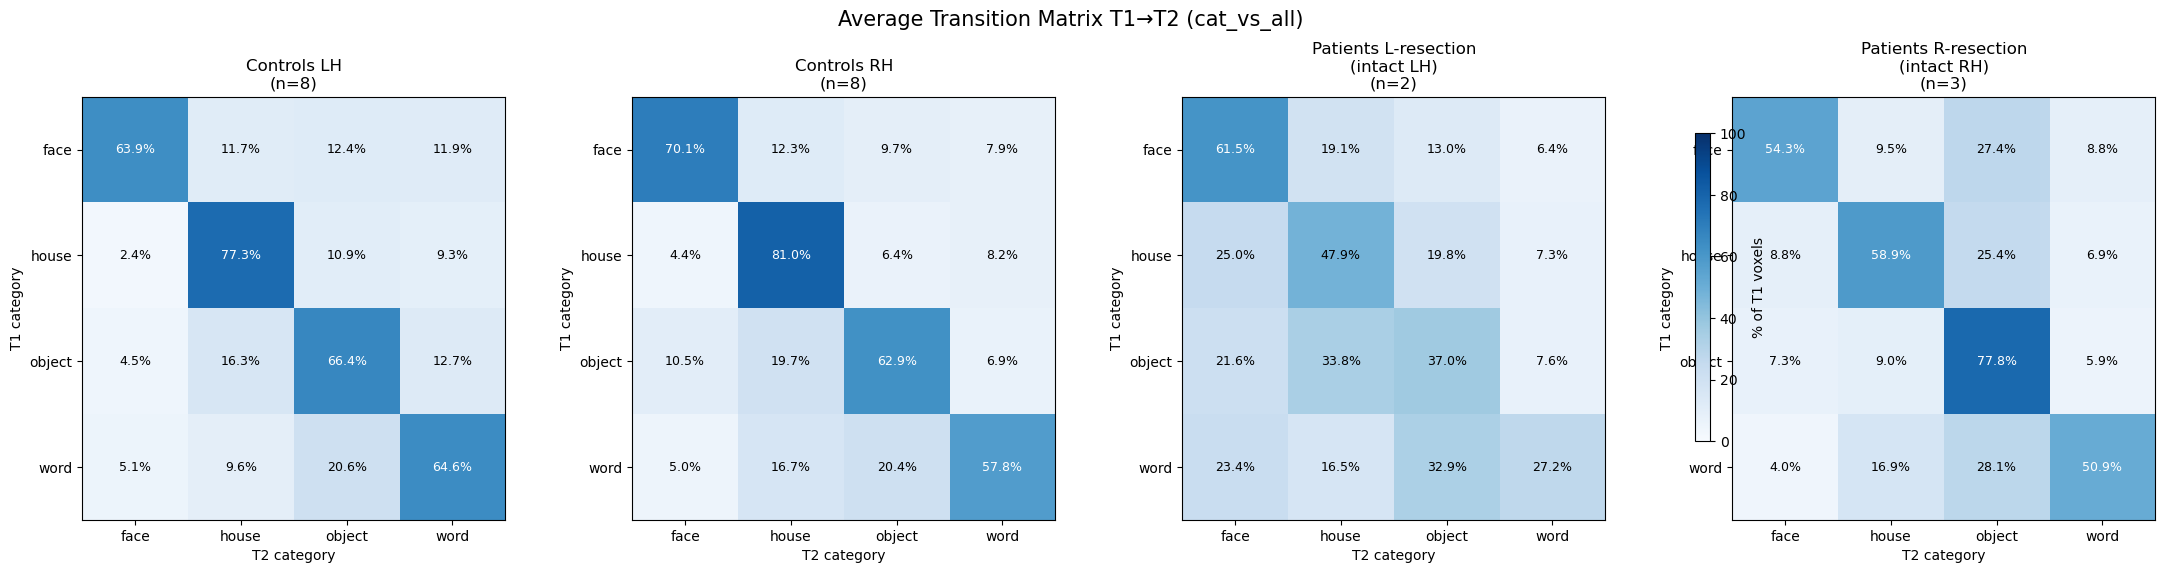

In [13]:
# ── Average transition matrix: split by group and resection side ──────────────

def avg_transition_matrix(results, group, hemi=None, surgery_side=None):
    """Average the percentage transition matrices across a group."""
    matrices = []
    sids = []
    for (sid, h), res in results.items():
        if res['group'] != group:
            continue
        if hemi is not None and h != hemi:
            continue
        if surgery_side is not None and res.get('surgery_side', 'na') != surgery_side:
            continue
        matrices.append(res['trans_pct'])
        sids.append(sid)

    if not matrices:
        return None, []
    return np.mean(matrices, axis=0), sids


panels = [
    ('Controls LH', 'control', 'l', None),
    ('Controls RH', 'control', 'r', None),
    ('Patients L-resection\n(intact LH)', 'OTC', 'l', 'right'),
    ('Patients R-resection\n(intact RH)', 'OTC', 'r', 'left'),
]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for ax, (title, group, hemi, surg) in zip(axes, panels):
    avg_mat, sids = avg_transition_matrix(transition_results, group, hemi, surg)
    if avg_mat is None:
        ax.set_title(f"{title}\n(no data)")
        ax.axis('off')
        continue

    im = ax.imshow(avg_mat, cmap='Blues', vmin=0, vmax=100)
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    ax.set_xticklabels(CATEGORIES, fontsize=10)
    ax.set_yticklabels(CATEGORIES, fontsize=10)
    ax.set_xlabel('T2 category')
    ax.set_ylabel('T1 category')
    ax.set_title(f'{title}\n(n={len(sids)})', fontsize=12)

    for i in range(4):
        for j in range(4):
            color = 'white' if avg_mat[i, j] > 50 else 'black'
            ax.text(j, i, f'{avg_mat[i, j]:.1f}%', ha='center', va='center',
                    fontsize=9, color=color)

    print(f"{title}: {', '.join(sids)}")

plt.colorbar(im, ax=axes, shrink=0.8, label='% of T1 voxels')
plt.suptitle(f'Average Transition Matrix T1→T2 ({ALLEGIANCE_COPE_SET})', fontsize=15, y=1.05)
plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'group_results',
            f'transition_matrix_split_{ALLEGIANCE_COPE_SET}.png'), dpi=150, bbox_inches='tight')
plt.show()



In [14]:
# ── Retention rates: split by resection side ─────────────────────────────────

retention_rows = []
for (sid, h), res in transition_results.items():
    for i, cat in enumerate(CATEGORIES):
        row_total = res['trans_counts'][i, :].sum()
        if row_total > 0:
            cat_retention = res['trans_counts'][i, i] / row_total
        else:
            cat_retention = np.nan
        retention_rows.append({
            'sub': sid,
            'hemi': h,
            'group': res['group'],
            'surgery_side': res.get('surgery_side', 'na'),
            'category': cat,
            'retention': cat_retention,
            'overall_retention': res['retention'],
        })

ret_df = pd.DataFrame(retention_rows)

print("=== RETENTION RATES (proportion voxels keeping same category T1→T2) ===\n")
print("Overall retention:")
print(ret_df.groupby(['group', 'surgery_side'])['overall_retention'].describe()[['mean', 'std', 'min', 'max']].round(3))

print("\nPer-category retention:")
pivot = ret_df.pivot_table(values='retention', index=['group', 'surgery_side'],
                           columns='category', aggfunc=['mean', 'std']).round(3)
print(pivot)



=== RETENTION RATES (proportion voxels keeping same category T1→T2) ===

Overall retention:
                       mean    std    min    max
group   surgery_side                            
OTC     left          0.637  0.117  0.482  0.740
        right         0.494  0.206  0.301  0.687
control na            0.704  0.078  0.564  0.831
nonOTC  left          0.748  0.013  0.731  0.766
        right         0.748  0.059  0.693  0.802

Per-category retention:
                       mean                         std                     
category               face  house object   word   face  house object   word
group   surgery_side                                                        
OTC     left          0.543  0.589  0.778  0.509  0.354  0.370  0.133  0.266
        right         0.615  0.479  0.370  0.272  0.265  0.362  0.385  0.256
control na            0.670  0.792  0.647  0.612  0.153  0.127  0.126  0.280
nonOTC  left          0.650  0.751  0.820  0.504  0.177  0.055  0.046  0.205
 

 ## 3. Individual Patient Transition Matrices

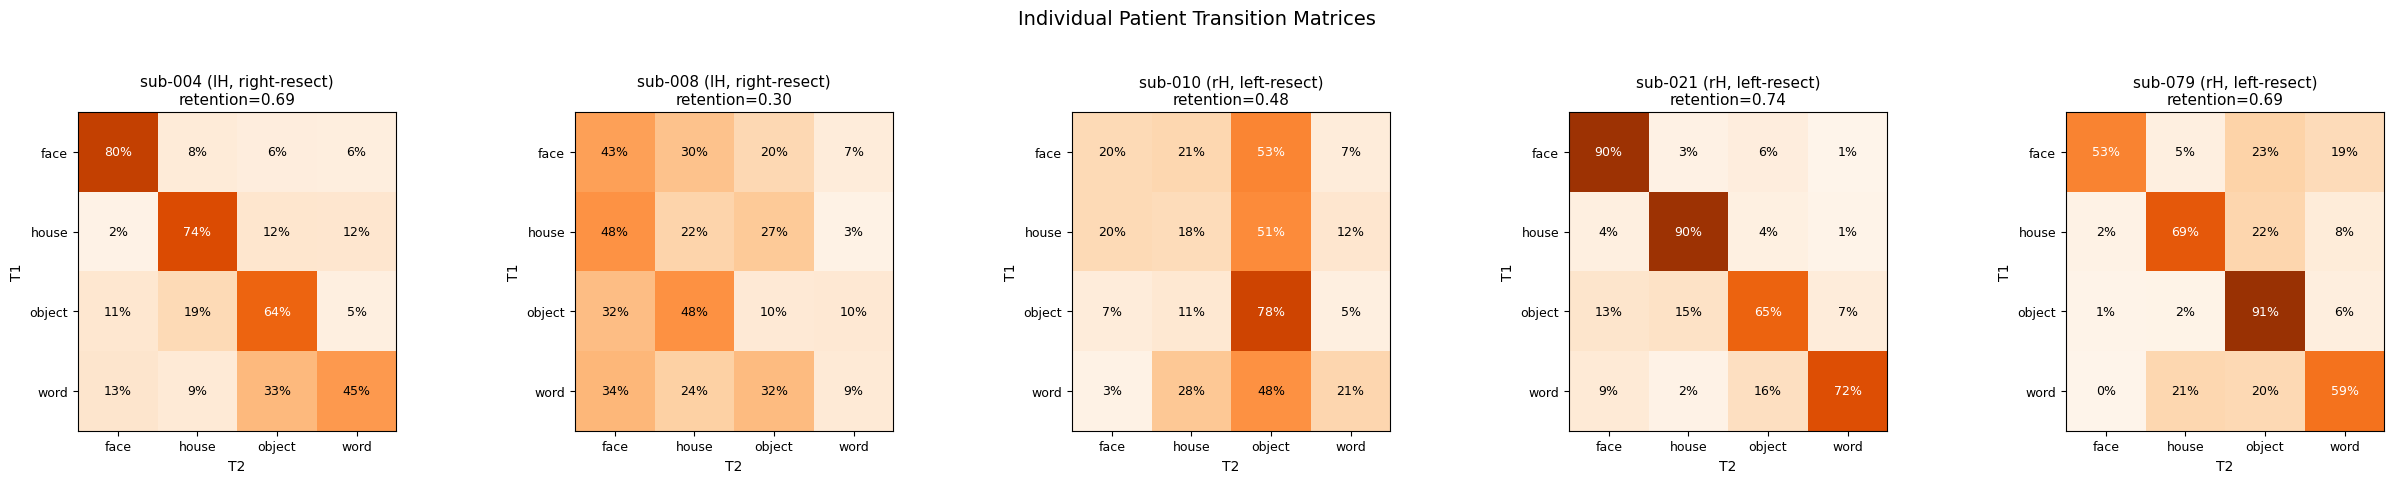

In [15]:
patient_trans = {k: v for k, v in transition_results.items() if v['group'] == 'OTC'}

if patient_trans:
    n_patients = len(patient_trans)
    fig, axes = plt.subplots(1, n_patients, figsize=(5 * n_patients, 4.5))
    if n_patients == 1:
        axes = [axes]

    for ax, ((sid, h), res) in zip(axes, patient_trans.items()):
        im = ax.imshow(res['trans_pct'], cmap='Oranges', vmin=0, vmax=100)
        ax.set_xticks(range(4))
        ax.set_yticks(range(4))
        ax.set_xticklabels(CATEGORIES, fontsize=9)
        ax.set_yticklabels(CATEGORIES, fontsize=9)
        ax.set_xlabel('T2')
        ax.set_ylabel('T1')
        surgery = res.get('surgery_side', '?')
        ax.set_title(f'{sid} ({h}H, {surgery}-resect)\n'
                     f'retention={res["retention"]:.2f}', fontsize=11)

        for i in range(4):
            for j in range(4):
                color = 'white' if res['trans_pct'][i, j] > 50 else 'black'
                ax.text(j, i, f'{res["trans_pct"][i, j]:.0f}%',
                        ha='center', va='center', fontsize=9, color=color)

    plt.suptitle('Individual Patient Transition Matrices', fontsize=14, y=1.05)
    plt.tight_layout()
    plt.savefig(os.path.join(processed_dir, 'group_results',
                f'patient_transitions_{ALLEGIANCE_COPE_SET}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()



 ## 4. Voxel Profile Stability

In [16]:
def compute_profile_stability(betas_t1, betas_t2):
    """
    For each voxel, compute cosine similarity of its 4-category response
    profile between T1 and T2.
    """
    mat_t1 = np.column_stack([betas_t1[cat] for cat in CATEGORIES])
    mat_t2 = np.column_stack([betas_t2[cat] for cat in CATEGORIES])

    dot_products = np.sum(mat_t1 * mat_t2, axis=1)
    norms_t1 = np.linalg.norm(mat_t1, axis=1)
    norms_t2 = np.linalg.norm(mat_t2, axis=1)

    denom = norms_t1 * norms_t2
    valid = denom > 0
    cos_sims = np.full(len(dot_products), np.nan)
    cos_sims[valid] = dot_products[valid] / denom[valid]

    return cos_sims, np.nanmean(cos_sims), np.nanmedian(cos_sims)



In [17]:
# ── Compute profile stability for longitudinal subjects ──────────────────────

stability_results = {}

for sid, info in long_subs.items():
    sessions = info['sessions']
    t1_ses, t2_ses = sessions[0], sessions[-1]
    actual_first = info['actual_first_ses']

    hemi = info['hemi'] if info['patient_status'] == 'OTC' else None
    hemis = [hemi] if hemi else ['l', 'r']

    for h in hemis:
        mask, affine = get_votc_mask(sid, actual_first, h)
        if mask is None:
            continue

        betas_t1 = load_category_betas(sid, t1_ses, actual_first, mask, cope_map)
        betas_t2 = load_category_betas(sid, t2_ses, actual_first, mask, cope_map)
        if betas_t1 is None or betas_t2 is None:
            continue

        cos_sims, mean_cos, median_cos = compute_profile_stability(betas_t1, betas_t2)

        stability_results[(sid, h)] = {
            'cos_sims': cos_sims,
            'mean_cos': mean_cos,
            'median_cos': median_cos,
            'group': info['patient_status'],
            'surgery_side': info.get('surgery_side', 'na'),
            'info': info,
        }

print(f"Computed profile stability for {len(stability_results)} entries")



Computed profile stability for 27 entries


In [18]:
# ── Profile stability: Controls vs Patients ──────────────────────────────────

stab_rows = []
for (sid, h), res in stability_results.items():
    stab_rows.append({
        'sub': sid,
        'hemi': h,
        'group': res['group'],
        'surgery_side': res.get('surgery_side', 'na'),
        'mean_cos_sim': res['mean_cos'],
        'median_cos_sim': res['median_cos'],
    })

stab_df = pd.DataFrame(stab_rows)

print("=== PROFILE STABILITY (cosine similarity T1 vs T2) ===\n")
print(stab_df.groupby(['group', 'surgery_side'])[['mean_cos_sim', 'median_cos_sim']].describe().round(3))



=== PROFILE STABILITY (cosine similarity T1 vs T2) ===

                     mean_cos_sim                                            \
                            count   mean    std    min    25%    50%    75%   
group   surgery_side                                                          
OTC     left                  3.0  0.339  0.232  0.074  0.258  0.441  0.472   
        right                 2.0  0.212  0.095  0.144  0.178  0.212  0.245   
control na                   16.0  0.464  0.107  0.266  0.404  0.467  0.548   
nonOTC  left                  4.0  0.492  0.082  0.384  0.467  0.500  0.525   
        right                 2.0  0.545  0.066  0.498  0.522  0.545  0.568   

                            median_cos_sim                                     \
                        max          count   mean    std    min    25%    50%   
group   surgery_side                                                            
OTC     left          0.502            3.0  0.475  0.326  0.102  0.3

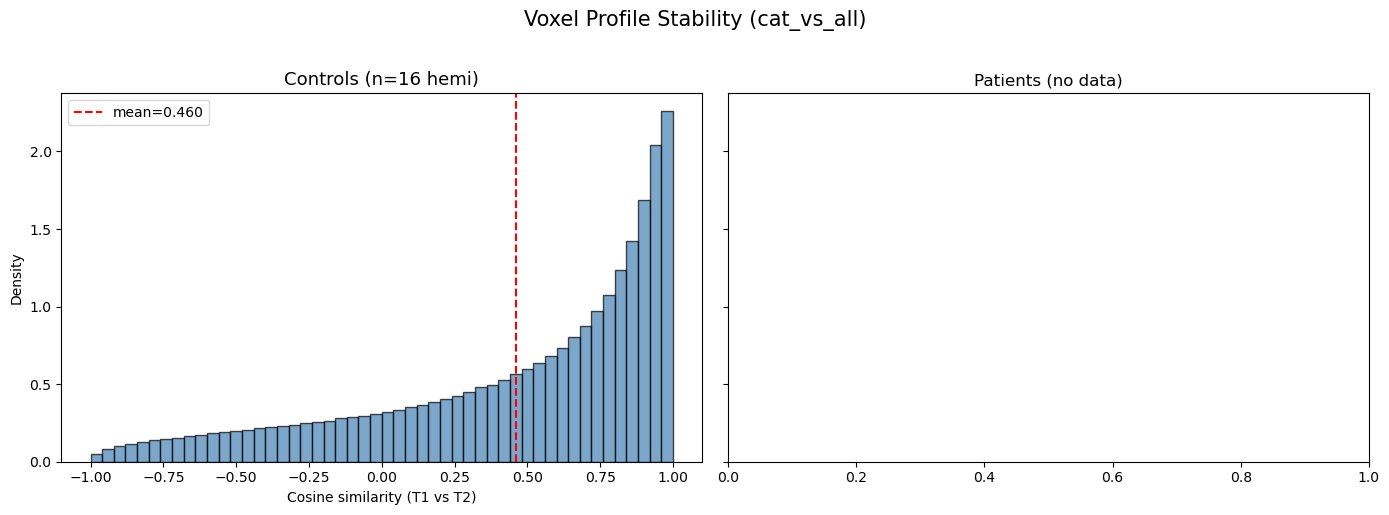

In [19]:
# ── Histogram of cosine similarities ─────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (title, group) in zip(axes, [('Controls', 'control'), ('Patients', 'patient')]):
    all_cos = []
    for (sid, h), res in stability_results.items():
        if res['group'] != group:
            continue
        all_cos.append(res['cos_sims'])

    if not all_cos:
        ax.set_title(f"{title} (no data)")
        continue

    pooled = np.concatenate(all_cos)
    pooled = pooled[np.isfinite(pooled)]

    ax.hist(pooled, bins=50, range=(-1, 1), density=True, alpha=0.7,
            color='steelblue', edgecolor='black')
    ax.axvline(np.mean(pooled), color='red', linestyle='--', label=f'mean={np.mean(pooled):.3f}')
    ax.set_xlabel('Cosine similarity (T1 vs T2)')
    ax.set_ylabel('Density')
    ax.set_title(f'{title} (n={len(all_cos)} hemi)', fontsize=13)
    ax.legend()

plt.suptitle(f'Voxel Profile Stability ({ALLEGIANCE_COPE_SET})', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'group_results',
            f'profile_stability_{ALLEGIANCE_COPE_SET}.png'), dpi=150, bbox_inches='tight')
plt.show()



 ## 5. Blauch-Style Summed Selectivity

In [20]:
def compute_summed_selectivity(betas, mask_size):
    """
    Blauch (2025) style: for each category, sum positive values across all
    VOTC voxels. Captures both territory and magnitude.
    """
    result = {}
    for cat in CATEGORIES:
        vals = betas[cat]
        positive_vals = vals[vals > 0]
        result[cat] = {
            'summed_sel': float(np.sum(positive_vals)),
            'n_positive': int(len(positive_vals)),
            'pct_positive': float(len(positive_vals) / mask_size * 100) if mask_size > 0 else 0,
            'mean_positive': float(np.mean(positive_vals)) if len(positive_vals) > 0 else 0,
        }
    return result



In [21]:
# ── Compute summed selectivity: longitudinal subjects, all sessions ──────────
# Always uses cat_vs_all copes (6-9) regardless of ALLEGIANCE_COPE_SET

sumsel_cope_map = CAT_VS_ALL_COPES

sumsel_rows = []

for sid, info in long_subs.items():
    sessions = info['sessions']
    actual_first = info['actual_first_ses']
    hemi = info['hemi'] if info['patient_status'] == 'OTC' else None
    hemis = [hemi] if hemi else ['l', 'r']

    for h in hemis:
        mask, affine = get_votc_mask(sid, actual_first, h)
        if mask is None:
            continue
        mask_size = int(mask.sum())

        for ses in sessions:
            betas = load_category_betas(sid, ses, actual_first, mask, sumsel_cope_map)
            if betas is None:
                continue

            ss = compute_summed_selectivity(betas, mask_size)

            for cat, vals in ss.items():
                sumsel_rows.append({
                    'sub': sid,
                    'ses': ses,
                    'hemi': h,
                    'group': info['patient_status'],
                    'surgery_side': info.get('surgery_side', 'na'),
                    'category': cat,
                    **vals,
                })

sumsel_df = pd.DataFrame(sumsel_rows)
if not sumsel_df.empty:
    print("=== SUMMED SELECTIVITY (cat_vs_all copes) ===\n")
    print("Longitudinal subjects, T1 vs T2:")

    for sid in sorted(long_subs.keys()):
        sub_df = sumsel_df[sumsel_df['sub'] == sid]
        if sub_df.empty:
            continue
        sessions = sorted(sub_df['ses'].unique())
        if len(sessions) < 2:
            continue

        group = long_subs[sid]['patient_status']
        surgery = long_subs[sid].get('surgery_side', 'na')
        hemis_used = sub_df['hemi'].unique()
        print(f"\n{sid} ({group}, {surgery}-resection, hemi={list(hemis_used)}):")
        for cat in CATEGORIES:
            t1_vals = sub_df[(sub_df['ses'] == sessions[0]) & (sub_df['category'] == cat)]['summed_sel']
            t2_vals = sub_df[(sub_df['ses'] == sessions[-1]) & (sub_df['category'] == cat)]['summed_sel']
            if t1_vals.empty or t2_vals.empty:
                print(f"  {cat:8s}: missing data")
                continue
            t1_val = t1_vals.iloc[0]
            t2_val = t2_vals.iloc[0]
            change = t2_val - t1_val
            print(f"  {cat:8s}: T1={t1_val:10.1f}  T2={t2_val:10.1f}  Δ={change:+10.1f}")



=== SUMMED SELECTIVITY (cat_vs_all copes) ===

Longitudinal subjects, T1 vs T2:

sub-004 (OTC, right-resection, hemi=['l']):
  face    : T1=   17878.8  T2=   55337.5  Δ=  +37458.8
  house   : T1=   97268.6  T2=  141323.5  Δ=  +44054.9
  object  : T1=   88763.3  T2=  135035.3  Δ=  +46272.0
  word    : T1=    9884.6  T2=   68831.2  Δ=  +58946.6

sub-007 (nonOTC, left-resection, hemi=['l', 'r']):
  face    : T1=   83756.2  T2=   79592.1  Δ=   -4164.1
  house   : T1=  150406.3  T2=   88697.7  Δ=  -61708.6
  object  : T1=  120616.3  T2=  109086.0  Δ=  -11530.3
  word    : T1=   46920.7  T2=   48914.5  Δ=   +1993.8

sub-008 (OTC, right-resection, hemi=['l']):
  face    : T1=  115467.2  T2=   63324.0  Δ=  -52143.2
  house   : T1=   89738.4  T2=   46493.6  Δ=  -43244.8
  object  : T1=   78081.3  T2=   32431.0  Δ=  -45650.3
  word    : T1=   21709.6  T2=   24119.9  Δ=   +2410.3

sub-010 (OTC, left-resection, hemi=['r']):
  face    : T1=   88875.1  T2=   46430.1  Δ=  -42445.0
  house   : T1=   6

 ## 6. Margin Analysis

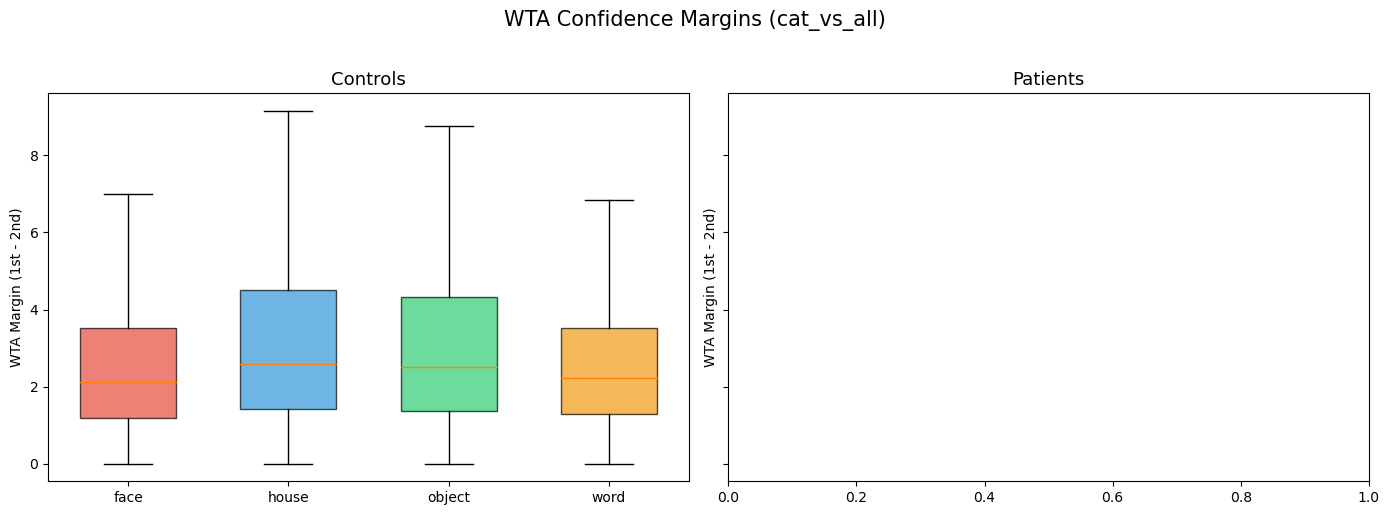

In [22]:
# ── Distribution of WTA margins: Controls vs Patients ────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, (title, group) in zip(axes, [('Controls', 'control'), ('Patients', 'patient')]):
    all_margins = {cat: [] for cat in CATEGORIES}

    for (sid, ses, h), res in wta_results.items():
        if res['group'] != group:
            continue
        for i, cat in enumerate(CATEGORIES):
            cat_mask = res['winners'] == i
            if cat_mask.sum() > 0:
                all_margins[cat].append(res['margin'][cat_mask])

    positions = []
    data = []
    colors = []
    for i, cat in enumerate(CATEGORIES):
        if all_margins[cat]:
            pooled = np.concatenate(all_margins[cat])
            data.append(pooled)
            positions.append(i)
            colors.append(CAT_COLORS[cat])

    if data:
        bp = ax.boxplot(data, positions=positions, widths=0.6, patch_artist=True,
                        showfliers=False)
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        ax.set_xticks(range(4))
        ax.set_xticklabels(CATEGORIES)

    ax.set_ylabel('WTA Margin (1st - 2nd)')
    ax.set_title(f'{title}', fontsize=13)

plt.suptitle(f'WTA Confidence Margins ({ALLEGIANCE_COPE_SET})', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'group_results',
            f'wta_margins_{ALLEGIANCE_COPE_SET}.png'), dpi=150, bbox_inches='tight')
plt.show()



 ## 7. Margin Change (Longitudinal)

In [23]:
margin_change_rows = []

for (sid, h), res in transition_results.items():
    for i, cat in enumerate(CATEGORIES):
        cat_at_t1 = res['winners_t1'] == i
        if cat_at_t1.sum() == 0:
            continue

        mean_margin_t1 = np.mean(res['margin_t1'][cat_at_t1])
        mean_margin_t2 = np.mean(res['margin_t2'][cat_at_t1])

        margin_change_rows.append({
            'sub': sid,
            'hemi': h,
            'group': res['group'],
            'surgery_side': res.get('surgery_side', 'na'),
            'category': cat,
            'mean_margin_t1': mean_margin_t1,
            'mean_margin_t2': mean_margin_t2,
            'margin_change': mean_margin_t2 - mean_margin_t1,
            'n_voxels': int(cat_at_t1.sum()),
        })

margin_df = pd.DataFrame(margin_change_rows)
if not margin_df.empty:
    print("=== MARGIN CHANGE T1→T2 ===")
    print("Positive = voxels became MORE committed, Negative = LESS committed\n")
    pivot = margin_df.pivot_table(values='margin_change',
                                   index=['group', 'surgery_side'],
                                   columns='category', aggfunc='mean').round(3)
    print(pivot)



=== MARGIN CHANGE T1→T2 ===
Positive = voxels became MORE committed, Negative = LESS committed

category               face  house  object   word
group   surgery_side                             
OTC     left         -0.260 -0.687  -0.226  0.019
        right        -0.276 -0.443   0.170 -0.437
control na            0.264  0.516  -0.414  0.059
nonOTC  left         -1.092 -2.193  -0.301 -0.897
        right         2.012  1.040   0.074  0.413


 ## 8. Summary Table

In [24]:
summary_rows = []

for sid, info in long_subs.items():
    hemi = info['hemi'] if info['patient_status'] == 'OTC' else None
    hemis = [hemi] if hemi else ['l', 'r']

    for h in hemis:
        row = {
            'sub': sid,
            'hemi': h,
            'group': info['patient_status'],
            'surgery_side': info.get('surgery_side', 'na'),
        }

        if (sid, h) in transition_results:
            row['overall_retention'] = transition_results[(sid, h)]['retention']
            for i, cat in enumerate(CATEGORIES):
                tc = transition_results[(sid, h)]['trans_counts']
                row_total = tc[i, :].sum()
                row[f'{cat}_retention'] = tc[i, i] / row_total if row_total > 0 else np.nan

        if (sid, h) in stability_results:
            row['mean_cos_sim'] = stability_results[(sid, h)]['mean_cos']
            row['median_cos_sim'] = stability_results[(sid, h)]['median_cos']

        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
out_path = os.path.join(processed_dir, 'group_results',
                         f'voxel_allegiance_summary_{ALLEGIANCE_COPE_SET}.csv')
summary_df.to_csv(out_path, index=False)
print(f"Saved summary table: {out_path}")
print()
print(summary_df.to_string(index=False))



Saved summary table: /user_data/csimmon2/sym_pt/group_results/voxel_allegiance_summary_cat_vs_all.csv

    sub hemi   group surgery_side  overall_retention  face_retention  house_retention  object_retention  word_retention  mean_cos_sim  median_cos_sim
sub-004    l     OTC        right           0.686572        0.803047         0.735093          0.641743        0.452381      0.279083        0.392509
sub-007    l  nonOTC         left           0.730902        0.633408         0.745210          0.824996        0.527546      0.383542        0.560662
sub-007    r  nonOTC         left           0.750431        0.690477         0.812028          0.762826        0.285714      0.582798        0.800704
sub-008    l     OTC        right           0.300840        0.427738         0.222849          0.097283        0.091013      0.144242        0.206833
sub-010    r     OTC         left           0.482153        0.195148         0.180124          0.775929        0.211953      0.074219        0.1023

 ## Notes on Interpretation



 **Cope set matters:**

 - `raw_beta`: Most neutral but noisy — all categories positive in most voxels

 - `cat_vs_all`: Best for allegiance — positive means this category wins

 - `differential`: face/house/word all vs object — not ideal for cross-category comparison



 **Run with all three and compare.** `cat_vs_all` is probably the most

 appropriate for allegiance claims. `raw_beta` is the most honest but noisiest.



 **The margin diagnostic:** If most voxels have tiny margins (Section 6),

 WTA is misleading. If margins are large, WTA is informative.



 **Connection to Blauch:** Summed selectivity (Section 5) is the

 territory-level version of the same question — how much total selectivity

 exists per category, without forcing each voxel to pick sides.

In [25]:
print("\n=== DONE ===")
print(f"Cope set used: {ALLEGIANCE_COPE_SET}")
print(f"All outputs saved to: {processed_dir}/group_results/")
print("\nTo run with a different cope set, change ALLEGIANCE_COPE_SET at the top")
print("Options: 'raw_beta', 'cat_vs_all', 'differential'")


=== DONE ===
Cope set used: cat_vs_all
All outputs saved to: /user_data/csimmon2/sym_pt/group_results/

To run with a different cope set, change ALLEGIANCE_COPE_SET at the top
Options: 'raw_beta', 'cat_vs_all', 'differential'


In [26]:
# ── Write WTA category maps as NIfTI volumes ─────────────────────────────────
# Each voxel gets a value: 1=face, 2=house, 3=object, 4=word, 0=unassigned
# Load in fsleyes with a custom LUT for the color overlay

wta_nifti_dir = os.path.join(processed_dir, 'group_results', 'wta_maps')
os.makedirs(wta_nifti_dir, exist_ok=True)

for sid, info in subjects.items():
    actual_first = info['actual_first_ses']
    hemi = info['hemi'] if info['patient_status'] == 'patient' else None
    hemis = [hemi] if hemi else ['l', 'r']
    
    for ses in info['sessions']:
        for h in hemis:
            mask, affine = get_votc_mask(sid, actual_first, h)
            if mask is None:
                continue
            
            betas = load_category_betas(sid, ses, actual_first, mask, cope_map)
            if betas is None:
                continue
            
            winners, margin, max_vals = compute_wta(betas, threshold)
            
            # Build full-brain volume
            brain_shape = mask.shape
            wta_vol = np.zeros(brain_shape, dtype=np.float32)
            margin_vol = np.zeros(brain_shape, dtype=np.float32)
            
            # Map: 0=unassigned, 1=face, 2=house, 3=object, 4=word
            voxel_coords = np.where(mask)
            for idx in range(len(winners)):
                cat_val = winners[idx] + 1 if winners[idx] >= 0 else 0  # shift to 1-indexed
                wta_vol[voxel_coords[0][idx], voxel_coords[1][idx], voxel_coords[2][idx]] = cat_val
                margin_vol[voxel_coords[0][idx], voxel_coords[1][idx], voxel_coords[2][idx]] = margin[idx]
            
            # Save
            tag = f'{sid}_ses-{ses}_{h}h'
            nib.save(nib.Nifti1Image(wta_vol, affine), 
                     os.path.join(wta_nifti_dir, f'{tag}_wta.nii.gz'))
            nib.save(nib.Nifti1Image(margin_vol, affine),
                     os.path.join(wta_nifti_dir, f'{tag}_margin.nii.gz'))

print(f"Saved WTA NIfTI volumes to: {wta_nifti_dir}")
print("Open in fsleyes: values 1=face, 2=house, 3=object, 4=word, 0=unassigned")

Saved WTA NIfTI volumes to: /user_data/csimmon2/sym_pt/group_results/wta_maps
Open in fsleyes: values 1=face, 2=house, 3=object, 4=word, 0=unassigned


In [27]:
# ── Nilearn ventral view: WTA maps per patient ──────────────────────────────
from nilearn import plotting
from matplotlib.colors import ListedColormap

# Custom colormap: 0=transparent, 1=face(red), 2=house(blue), 3=object(green), 4=word(orange)
wta_cmap = ListedColormap(['#000000', '#E74C3C', '#3498DB', '#2ECC71', '#F39C12'])

patient_sids = sorted([sid for sid, info in subjects.items() 
                        if info['patient_status'] == 'patient'])

for sid in patient_sids:
    info = subjects[sid]
    actual_first = info['actual_first_ses']
    h = info['hemi']
    first_ses = info['sessions'][0]
    
    # Load T1 as background
    t1_path = os.path.join(processed_dir, sid, f'ses-{actual_first}', 'anat', 'T1w_brain.nii.gz')
    wta_path = os.path.join(wta_nifti_dir, f'{sid}_ses-{first_ses}_{h}h_wta.nii.gz')
    
    if not os.path.exists(t1_path) or not os.path.exists(wta_path):
        print(f"  SKIP {sid}: missing files")
        continue
    
    wta_img = nib.load(wta_path)
    t1_img = nib.load(t1_path)
    
    # Find ventral slices with data — look for axial slices with most WTA voxels
    wta_data = wta_img.get_fdata()
    z_counts = [(z, np.sum(wta_data[:, :, z] > 0)) for z in range(wta_data.shape[2])]
    z_counts.sort(key=lambda x: x[1], reverse=True)
    # Pick top 5 slices with most voxels
    best_slices = sorted([z for z, c in z_counts[:5]])
    
    surgery = info.get('surgery_side', '?')
    
    fig, axes = plt.subplots(1, len(best_slices), figsize=(4 * len(best_slices), 4))
    if len(best_slices) == 1:
        axes = [axes]
    
    for ax, z_slice in zip(axes, best_slices):
        # Get the slice data
        t1_slice = t1_img.get_fdata()[:, :, z_slice]
        wta_slice = wta_data[:, :, z_slice]
        
        # Plot T1 background
        ax.imshow(np.rot90(t1_slice), cmap='gray', aspect='equal')
        
        # Overlay WTA with transparency for 0 values
        wta_masked = np.ma.masked_where(wta_slice == 0, wta_slice)
        ax.imshow(np.rot90(wta_masked), cmap=wta_cmap, vmin=0, vmax=4, 
                  aspect='equal', alpha=0.7)
        
        ax.set_title(f'z={z_slice}', fontsize=9)
        ax.axis('off')
    
    # Legend
    legend_patches = [Patch(facecolor=c, label=cat) 
                      for cat, c in zip(CATEGORIES, ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12'])]
    fig.legend(handles=legend_patches, loc='lower center', ncol=4, fontsize=10)
    
    plt.suptitle(f'{sid} ({surgery}-resect, {h}H) — WTA Map ({ALLEGIANCE_COPE_SET})', fontsize=12)
    plt.tight_layout(rect=[0, 0.05, 1, 0.95])
    plt.savefig(os.path.join(wta_nifti_dir, f'{sid}_wta_slices.png'), dpi=150, bbox_inches='tight')
    plt.show()

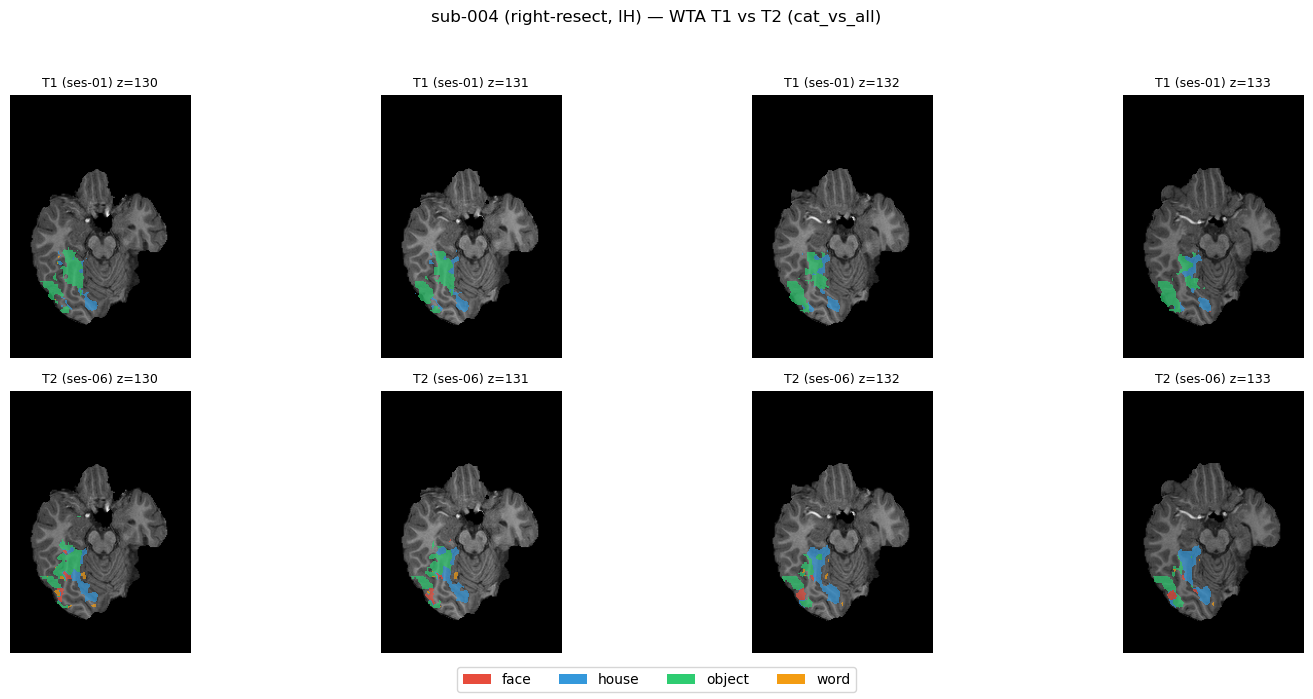

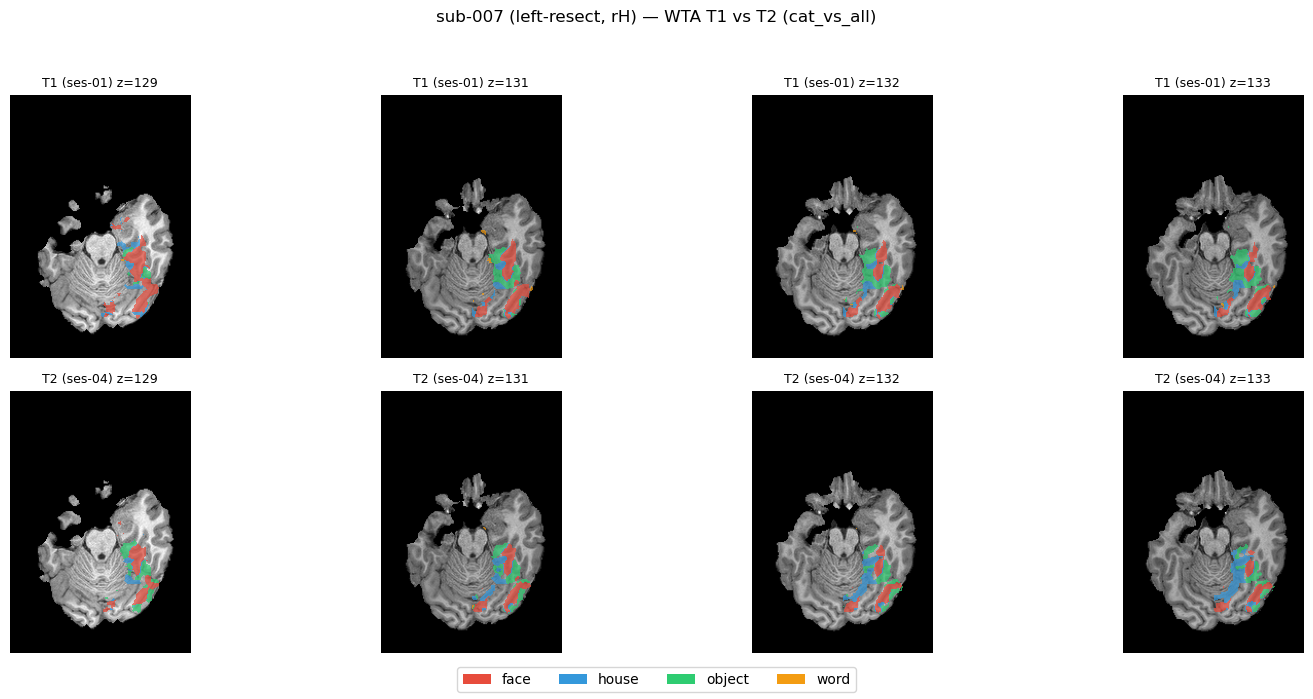

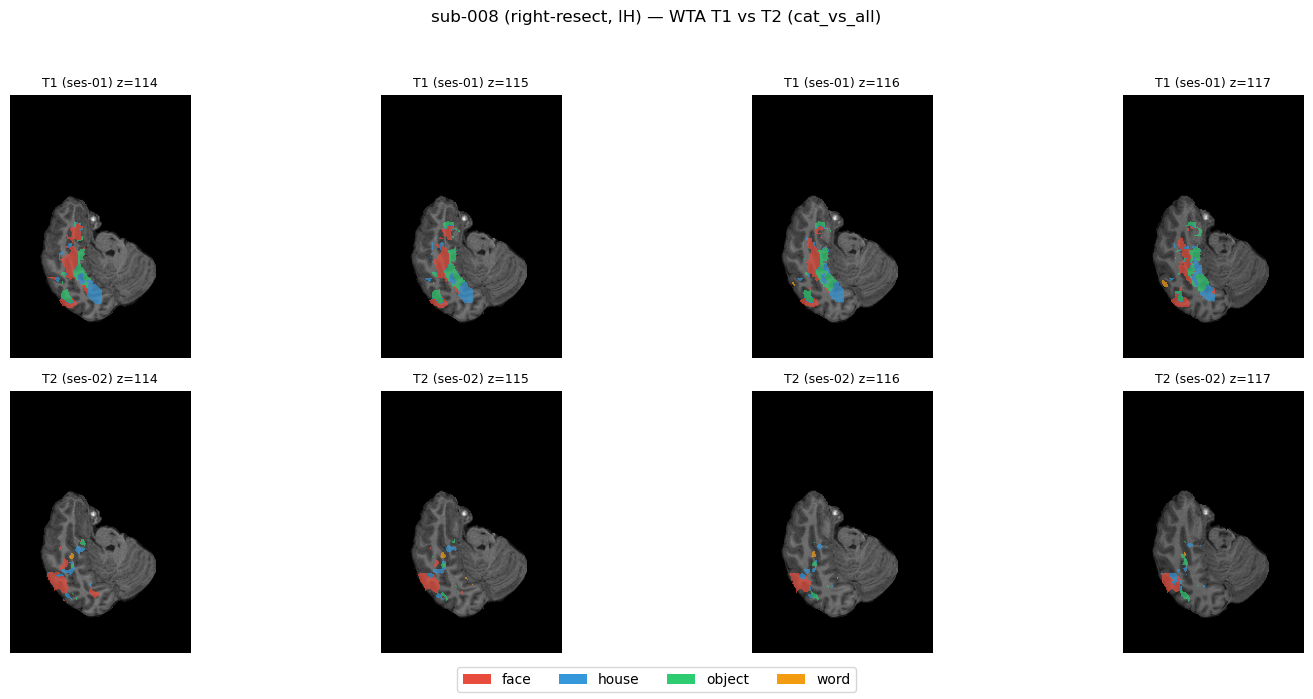

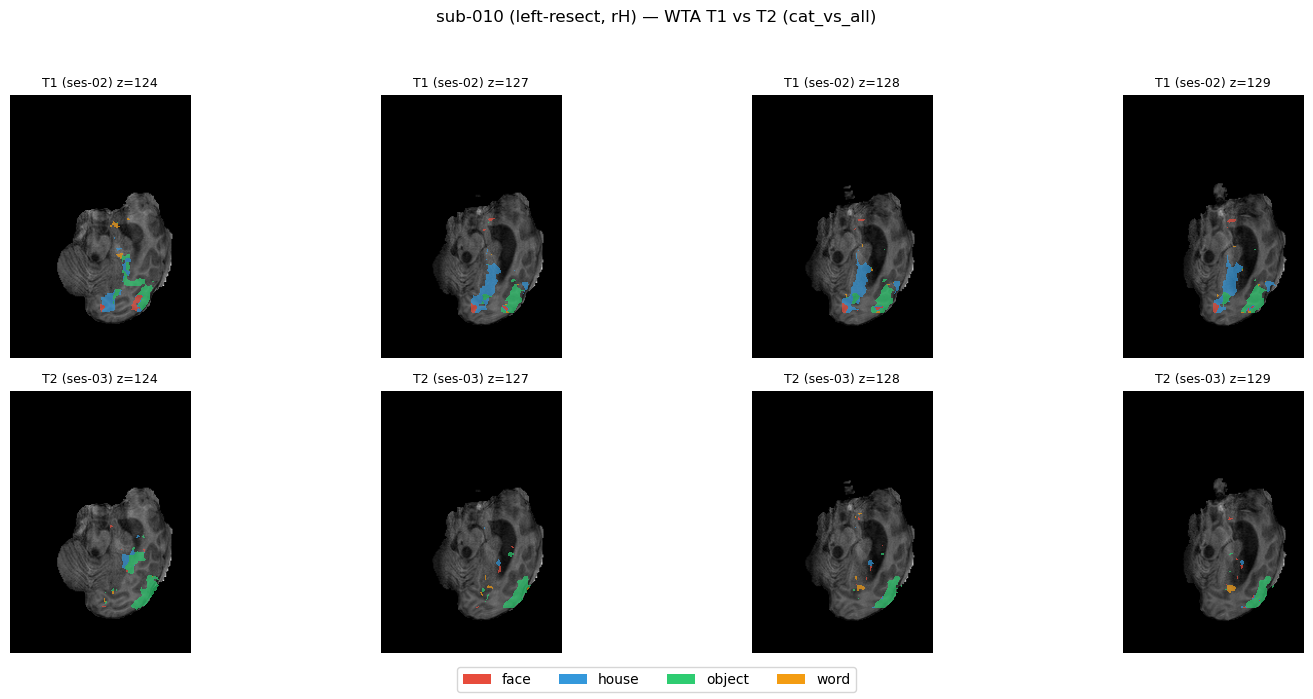

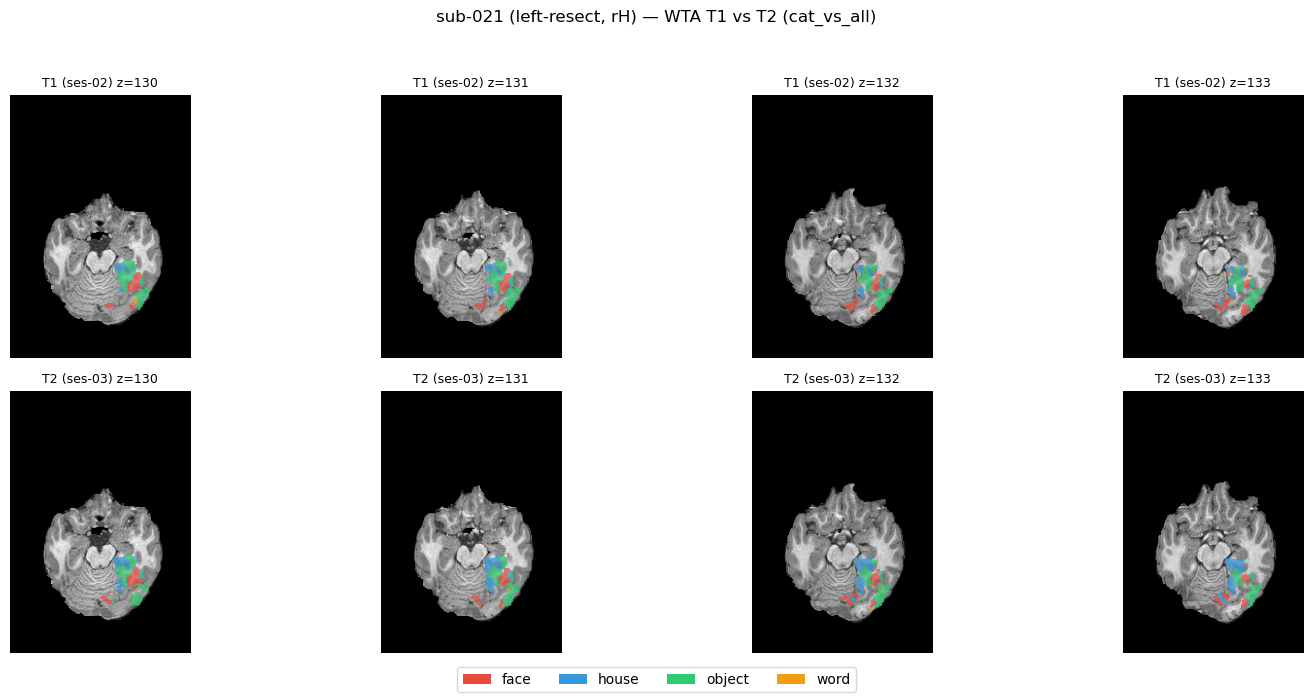

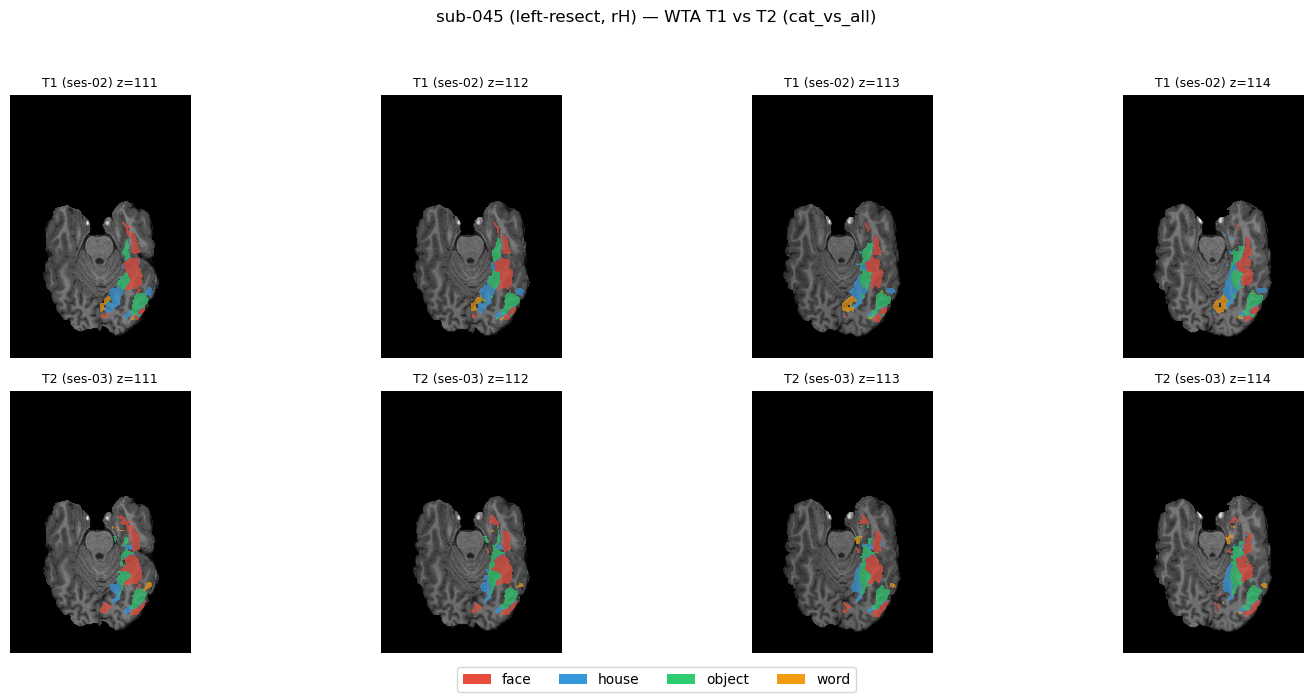

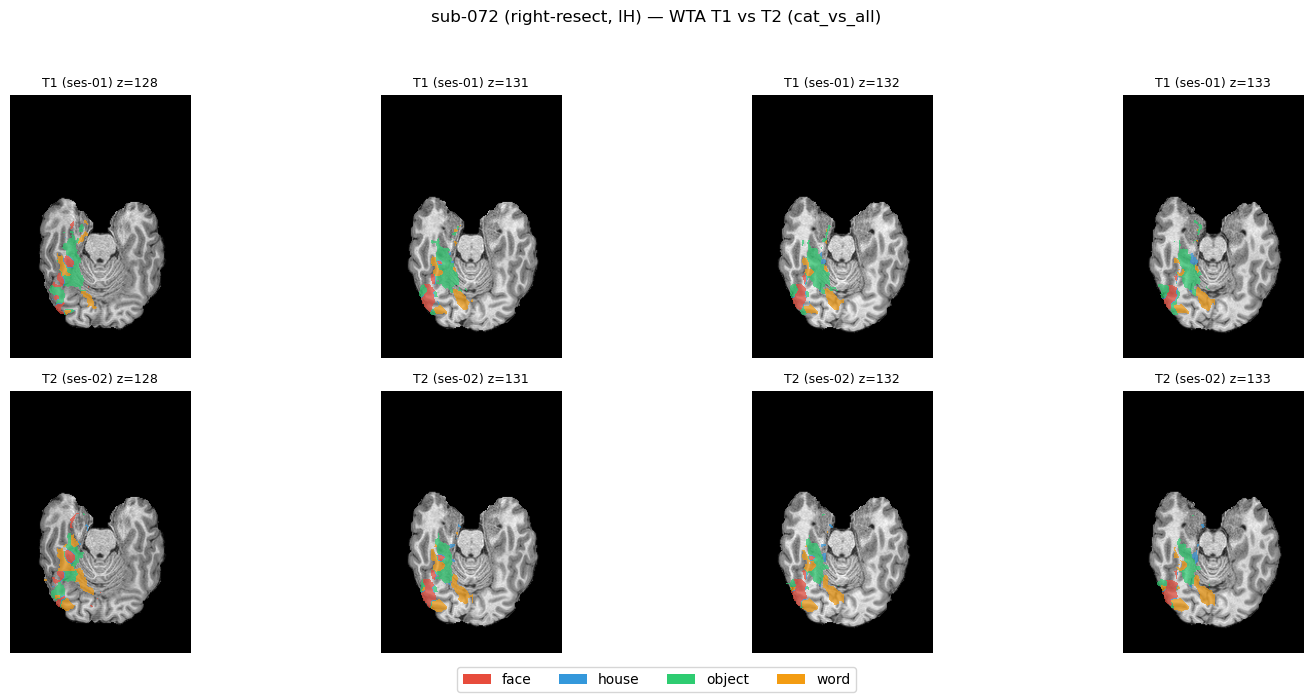

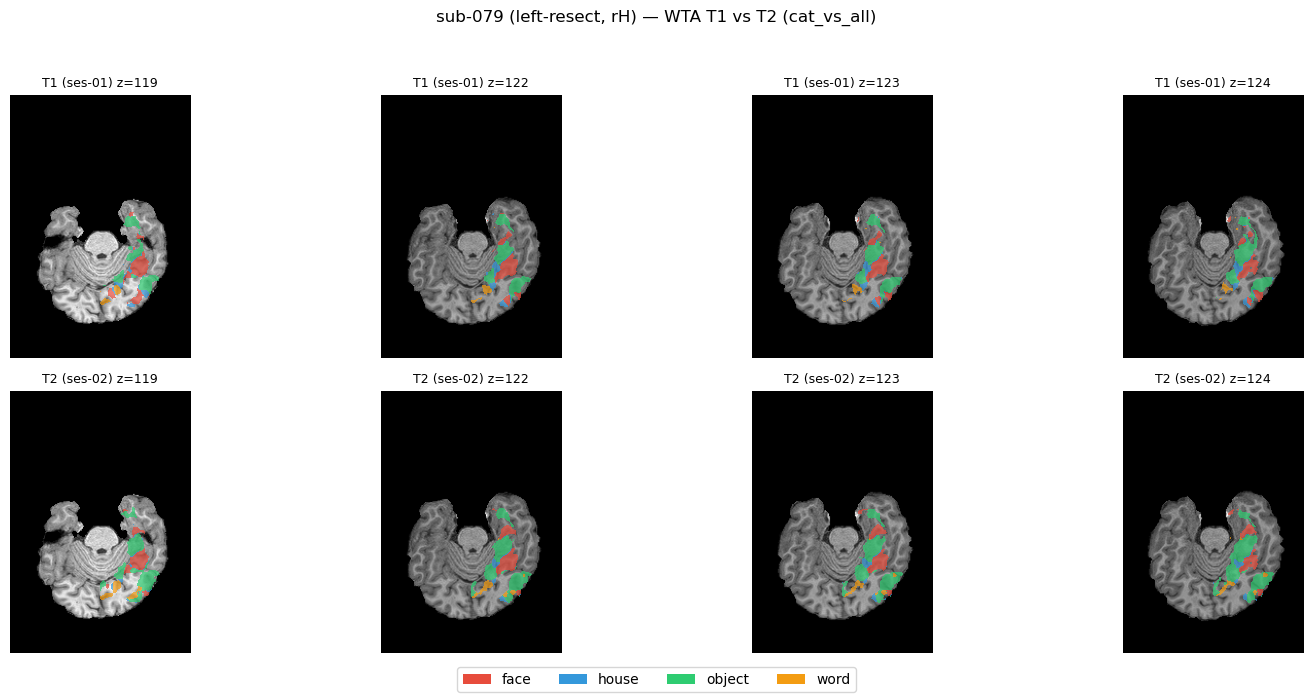

In [28]:
# ── T1 vs T2 WTA slice comparison per patient ────────────────────────────────

for sid in sorted(long_subs.keys()):
    info = long_subs[sid]
    if info['patient_status'] == 'control':
        continue
    
    actual_first = info['actual_first_ses']
    h = info['hemi']
    sessions = info['sessions']
    t1_ses, t2_ses = sessions[0], sessions[-1]
    surgery = info.get('surgery_side', '?')
    
    t1_path = os.path.join(processed_dir, sid, f'ses-{actual_first}', 'anat', 'T1w_brain.nii.gz')
    wta_t1_path = os.path.join(wta_nifti_dir, f'{sid}_ses-{t1_ses}_{h}h_wta.nii.gz')
    wta_t2_path = os.path.join(wta_nifti_dir, f'{sid}_ses-{t2_ses}_{h}h_wta.nii.gz')
    
    if not all(os.path.exists(p) for p in [t1_path, wta_t1_path, wta_t2_path]):
        print(f"  SKIP {sid}: missing files")
        continue
    
    t1_img = nib.load(t1_path)
    wta_t1_data = nib.load(wta_t1_path).get_fdata()
    wta_t2_data = nib.load(wta_t2_path).get_fdata()
    t1_brain = t1_img.get_fdata()
    
    # Find best slices using T1 WTA data
    z_counts = [(z, np.sum(wta_t1_data[:, :, z] > 0)) for z in range(wta_t1_data.shape[2])]
    z_counts.sort(key=lambda x: x[1], reverse=True)
    best_slices = sorted([z for z, c in z_counts[:4]])
    
    fig, axes = plt.subplots(2, len(best_slices), figsize=(4 * len(best_slices), 7))
    
    for col, z_slice in enumerate(best_slices):
        for row, (wta_data, label) in enumerate([(wta_t1_data, f'T1 (ses-{t1_ses})'),
                                                   (wta_t2_data, f'T2 (ses-{t2_ses})')]):
            ax = axes[row, col]
            ax.imshow(np.rot90(t1_brain[:, :, z_slice]), cmap='gray', aspect='equal')
            wta_masked = np.ma.masked_where(wta_data[:, :, z_slice] == 0, 
                                             wta_data[:, :, z_slice])
            ax.imshow(np.rot90(wta_masked), cmap=wta_cmap, vmin=0, vmax=4,
                      aspect='equal', alpha=0.7)
            ax.set_title(f'{label} z={z_slice}', fontsize=9)
            ax.axis('off')
    
    legend_patches = [Patch(facecolor=c, label=cat)
                      for cat, c in zip(CATEGORIES, ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12'])]
    fig.legend(handles=legend_patches, loc='lower center', ncol=4, fontsize=10)
    plt.suptitle(f'{sid} ({surgery}-resect, {h}H) — WTA T1 vs T2 ({ALLEGIANCE_COPE_SET})', fontsize=12)
    plt.tight_layout(rect=[0, 0.04, 1, 0.95])
    plt.savefig(os.path.join(wta_nifti_dir, f'{sid}_wta_t1vt2_slices.png'), dpi=150, bbox_inches='tight')
    plt.show()

Computing individual RDMs...


Individual RDMs computed: 66
  OTC-L: 8
  OTC-R: 7
  control: 42
  nonOTC: 9

=== GROUP-AVERAGE RDMs (1 - correlation) ===

control (n=42):
         face  house  object   word
face    0.000  0.210   0.177  0.208
house   0.210  0.000   0.165  0.286
object  0.177  0.165   0.000  0.204
word    0.208  0.286   0.204  0.000

OTC-R (n=7):
         face  house  object   word
face    0.000  0.273   0.202  0.206
house   0.273  0.000   0.184  0.310
object  0.202  0.184   0.000  0.236
word    0.206  0.310   0.236  0.000

OTC-L (n=8):
         face  house  object   word
face    0.000  0.243   0.225  0.274
house   0.243  0.000   0.174  0.343
object  0.225  0.174   0.000  0.303
word    0.274  0.343   0.303  0.000

nonOTC (n=9):
         face  house  object   word
face    0.000  0.247   0.195  0.222
house   0.247  0.000   0.169  0.284
object  0.195  0.169   0.000  0.172
word    0.222  0.284   0.172  0.000

MANTEL TESTS: Subgroup RDM vs Control RDM
Control n=42 (hemisphere-entries)
Note: 4 categories →

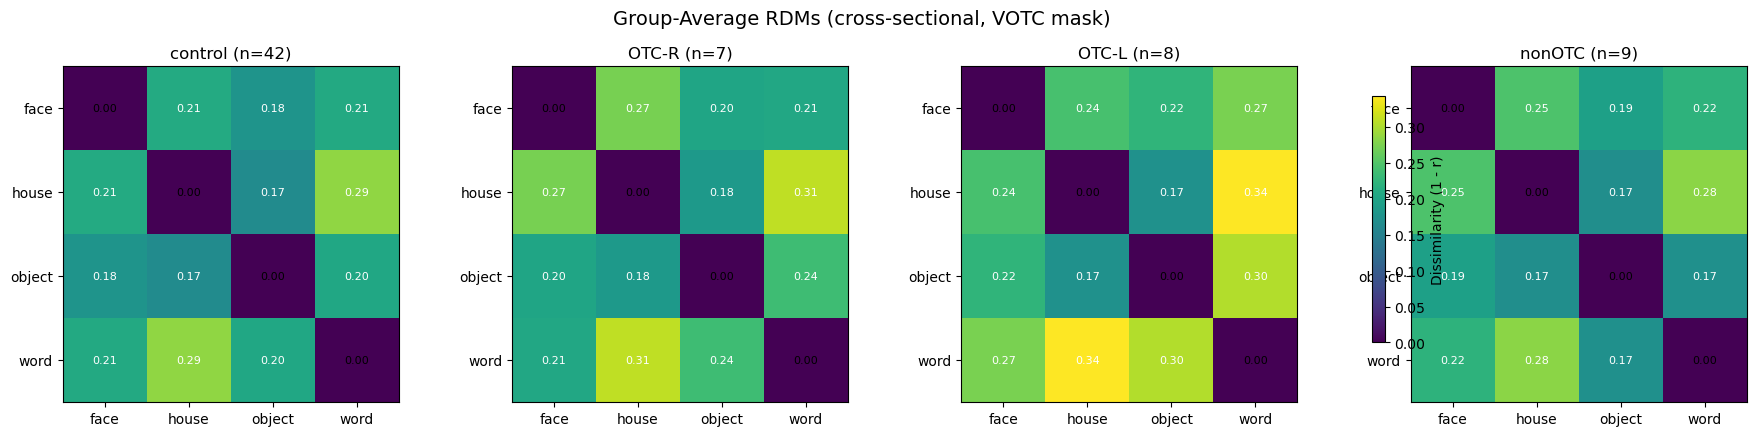

In [29]:
# ── Mantel Test: OTC subgroup RDMs vs Control RDM ────────────────────────────
# 
# Computes a 4×4 RDM per subject from spatial patterns within the VOTC mask,
# then tests whether OTC-R and OTC-L group-average RDMs correlate with the
# control group-average RDM.
#
# Two approaches reported:
#   (A) Average individual RDMs → correlate group means
#   (B) Compute group-level RDM from concatenated/averaged patterns
#
# Mantel significance via permutation (shuffle category labels).

from scipy.stats import spearmanr, pearsonr
from itertools import combinations

# ── Step 1: Compute individual 4×4 RDMs ──────────────────────────────────────

RSA_COPES = {'face': 15, 'house': 16, 'object': 17, 'word': 18}

def compute_rdm(sub_id, session, actual_first_ses, mask):
    """
    Compute a 4×4 RDM from raw beta patterns (copes 15-18) within mask.
    RDM cells = 1 - Pearson correlation between spatial patterns.
    """
    feat_dir = os.path.join(processed_dir, sub_id, f'ses-{session}',
                            'derivatives', 'fsl', 'loc', 'HighLevel.gfeat')
    
    # Always use cope files (raw betas), not zstats
    stat_file = 'cope1.nii.gz' if session == actual_first_ses else f'cope1_ses{actual_first_ses}.nii.gz'
    
    patterns = {}
    for cat, cope_num in RSA_COPES.items():
        fpath = os.path.join(feat_dir, f'cope{cope_num}.feat', 'stats', stat_file)
        if not os.path.exists(fpath):
            return None
        data = nib.load(fpath).get_fdata()
        pattern = data[mask]
        if not np.all(np.isfinite(pattern)):
            pattern = pattern[np.isfinite(pattern)]
        patterns[cat] = pattern
    
    # Check all patterns same length
    lengths = [len(v) for v in patterns.values()]
    if len(set(lengths)) > 1 or lengths[0] == 0:
        return None
    
    # Build 4×4 RDM (1 - correlation)
    cats = list(RSA_COPES.keys())
    rdm = np.zeros((4, 4))
    for i, cat_i in enumerate(cats):
        for j, cat_j in enumerate(cats):
            if i == j:
                rdm[i, j] = 0
            elif i < j:
                r, _ = pearsonr(patterns[cat_i], patterns[cat_j])
                rdm[i, j] = 1 - r
                rdm[j, i] = 1 - r
    
    return rdm


print("Computing individual RDMs...")
individual_rdms = {}

for sid, info in subjects.items():
    first_ses = info['sessions'][0]
    actual_first = info['actual_first_ses']
    hemi = info['hemi'] if info['patient_status'] != 'control' else None
    hemis = [hemi] if hemi else ['l', 'r']
    
    for h in hemis:
        mask, affine = get_votc_mask(sid, actual_first, h)
        if mask is None or mask.sum() == 0:
            continue
        
        rdm = compute_rdm(sid, first_ses, actual_first, mask)
        if rdm is None:
            continue
        
        # Determine subgroup
        group = info.get('group', info['patient_status'])
        surgery = info.get('surgery_side', 'na')
        
        # OTC-R = intact RH = left resection (surgery_side='left' is wrong label...
        # let's use the actual field)
        # OTC with intact RH means surgery was on left
        if group == 'OTC':
            if info['intact_hemi'] == 'right':
                subgroup = 'OTC-R'  # intact RH, left resection
            else:
                subgroup = 'OTC-L'  # intact LH, right resection
        elif group == 'nonOTC':
            subgroup = 'nonOTC'
        else:
            subgroup = 'control'
        
        individual_rdms[(sid, h)] = {
            'rdm': rdm,
            'subgroup': subgroup,
            'group': group,
            'hemi': h,
        }

# Count per subgroup
from collections import Counter
subgroup_counts = Counter(v['subgroup'] for v in individual_rdms.values())
print(f"Individual RDMs computed: {len(individual_rdms)}")
for sg, count in sorted(subgroup_counts.items()):
    print(f"  {sg}: {count}")


# ── Step 2: Compute group-average RDMs ────────────────────────────────────────

def get_group_avg_rdm(individual_rdms, subgroup):
    """Average RDMs within a subgroup."""
    rdms = [v['rdm'] for v in individual_rdms.values() if v['subgroup'] == subgroup]
    if not rdms:
        return None, 0
    return np.mean(rdms, axis=0), len(rdms)


cats = list(RSA_COPES.keys())

print("\n=== GROUP-AVERAGE RDMs (1 - correlation) ===\n")
for sg in ['control', 'OTC-R', 'OTC-L', 'nonOTC']:
    avg_rdm, n = get_group_avg_rdm(individual_rdms, sg)
    if avg_rdm is None:
        print(f"{sg}: no data")
        continue
    print(f"{sg} (n={n}):")
    df_rdm = pd.DataFrame(avg_rdm, index=cats, columns=cats).round(3)
    print(df_rdm)
    print()


# ── Step 3: Mantel test — correlate upper triangles with permutation ─────────

def get_upper_triangle(rdm):
    """Extract upper triangle of a 4×4 RDM (6 values)."""
    indices = np.triu_indices(4, k=1)
    return rdm[indices]


def mantel_test(rdm1, rdm2, n_perm=10000):
    """
    Mantel test: Pearson correlation of upper triangles, 
    significance by row/column permutation of one RDM.
    
    Note: with 4 categories, upper triangle has only 6 values,
    so degrees of freedom are very limited.
    """
    vec1 = get_upper_triangle(rdm1)
    vec2 = get_upper_triangle(rdm2)
    
    observed_r, _ = pearsonr(vec1, vec2)
    
    # Permutation test: shuffle rows and columns of rdm2
    count = 0
    for _ in range(n_perm):
        perm = np.random.permutation(4)
        rdm2_perm = rdm2[np.ix_(perm, perm)]
        vec2_perm = get_upper_triangle(rdm2_perm)
        perm_r, _ = pearsonr(vec1, vec2_perm)
        if perm_r >= observed_r:
            count += 1
    
    p_val = count / n_perm
    return observed_r, p_val


ctrl_rdm, n_ctrl = get_group_avg_rdm(individual_rdms, 'control')

print("=" * 60)
print("MANTEL TESTS: Subgroup RDM vs Control RDM")
print(f"Control n={n_ctrl} (hemisphere-entries)")
print(f"Note: 4 categories → 6 upper-triangle values → limited df")
print("=" * 60)

# Approach A: Average individual RDMs, then correlate
print("\n--- Approach A: Average individual RDMs, then Mantel ---")
for sg in ['OTC-R', 'OTC-L', 'nonOTC']:
    sg_rdm, n_sg = get_group_avg_rdm(individual_rdms, sg)
    if sg_rdm is None:
        continue
    r, p = mantel_test(ctrl_rdm, sg_rdm)
    sig = ' *' if p < .05 else ''
    print(f"  {sg:8s} (n={n_sg}): r = {r:.3f}, p = {p:.4f}{sig}")

# Approach B: Correlate each individual patient RDM with control average
print("\n--- Approach B: Individual patient RDMs vs Control average ---")
for (sid, h), info in sorted(individual_rdms.items()):
    if info['subgroup'] not in ['OTC-R', 'OTC-L']:
        continue
    vec_ctrl = get_upper_triangle(ctrl_rdm)
    vec_pt = get_upper_triangle(info['rdm'])
    r, _ = pearsonr(vec_ctrl, vec_pt)
    print(f"  {sid} ({h}H, {info['subgroup']}): r = {r:.3f}")


# ── Step 4: Visualize group RDMs ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, sg in zip(axes, ['control', 'OTC-R', 'OTC-L', 'nonOTC']):
    avg_rdm, n = get_group_avg_rdm(individual_rdms, sg)
    if avg_rdm is None:
        ax.set_title(f'{sg}\n(no data)')
        ax.axis('off')
        continue
    
    im = ax.imshow(avg_rdm, cmap='viridis', vmin=0, 
                   vmax=np.max([get_group_avg_rdm(individual_rdms, s)[0].max() 
                               for s in ['control', 'OTC-R', 'OTC-L', 'nonOTC']
                               if get_group_avg_rdm(individual_rdms, s)[0] is not None]))
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    ax.set_xticklabels(cats, fontsize=10)
    ax.set_yticklabels(cats, fontsize=10)
    ax.set_title(f'{sg} (n={n})', fontsize=12)
    
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f'{avg_rdm[i,j]:.2f}', ha='center', va='center',
                    fontsize=8, color='white' if avg_rdm[i,j] > avg_rdm.max()*0.5 else 'black')

plt.colorbar(im, ax=axes, shrink=0.8, label='Dissimilarity (1 - r)')
plt.suptitle('Group-Average RDMs (cross-sectional, VOTC mask)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'group_results',
            f'mantel_group_rdms_{ALLEGIANCE_COPE_SET}.png'), dpi=150, bbox_inches='tight')
plt.show()

In [30]:
from scipy.stats import t as t_dist

def bootstrap_ci(data, n_boot=5000, ci=95):
    data = np.array(data)
    data = data[np.isfinite(data)]
    if len(data) < 2:
        return np.nanmean(data), np.nan, np.nan
    boot_means = np.array([np.mean(np.random.choice(data, size=len(data), replace=True)) 
                           for _ in range(n_boot)])
    lower = np.percentile(boot_means, (100 - ci) / 2)
    upper = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return np.nanmean(data), lower, upper

def crawford_t(patient_val, ctrl_vals):
    n = len(ctrl_vals)
    ctrl_mean = np.mean(ctrl_vals)
    ctrl_std = np.std(ctrl_vals, ddof=1)
    if ctrl_std == 0:
        return np.nan, np.nan
    t = (patient_val - ctrl_mean) / (ctrl_std * np.sqrt((n + 1) / n))
    p = 2 * t_dist.sf(abs(t), df=n - 1)
    return t, p

def permutation_test(group1, group2, n_perm=10000):
    group1 = np.array(group1)[np.isfinite(group1)]
    group2 = np.array(group2)[np.isfinite(group2)]
    observed_diff = np.mean(group1) - np.mean(group2)
    combined = np.concatenate([group1, group2])
    n1 = len(group1)
    count = 0
    for _ in range(n_perm):
        np.random.shuffle(combined)
        perm_diff = np.mean(combined[:n1]) - np.mean(combined[n1:])
        if abs(perm_diff) >= abs(observed_diff):
            count += 1
    return observed_diff, count / n_perm

PER-CATEGORY RETENTION

       Sub    Group     Face    House   Object     Word  Overall
   sub-004      OTC    0.803    0.735    0.642    0.452    0.687
   sub-008      OTC    0.428    0.223    0.097    0.091    0.301
   sub-010      OTC    0.195    0.180    0.776    0.212    0.482
   sub-021      OTC    0.902    0.902    0.646    0.725    0.740
   sub-079      OTC    0.533    0.685    0.913    0.591    0.690
   sub-018  control    0.494    0.894    0.473    0.470    0.645
   sub-022  control    0.580    0.828    0.737    0.183    0.643
   sub-025  control    0.697    0.755    0.719    0.427    0.726
   sub-052  control    0.862    0.705    0.706    0.847    0.759
   sub-058  control    0.786    0.721    0.821    0.627    0.790
   sub-062  control    0.802    0.924    0.564    0.899    0.795
   sub-064  control    0.434    0.572    0.578    0.847    0.575
   sub-068  control    0.704    0.936    0.575    0.598    0.697
   sub-007   nonOTC    0.690    0.812    0.763    0.286    0.750
 

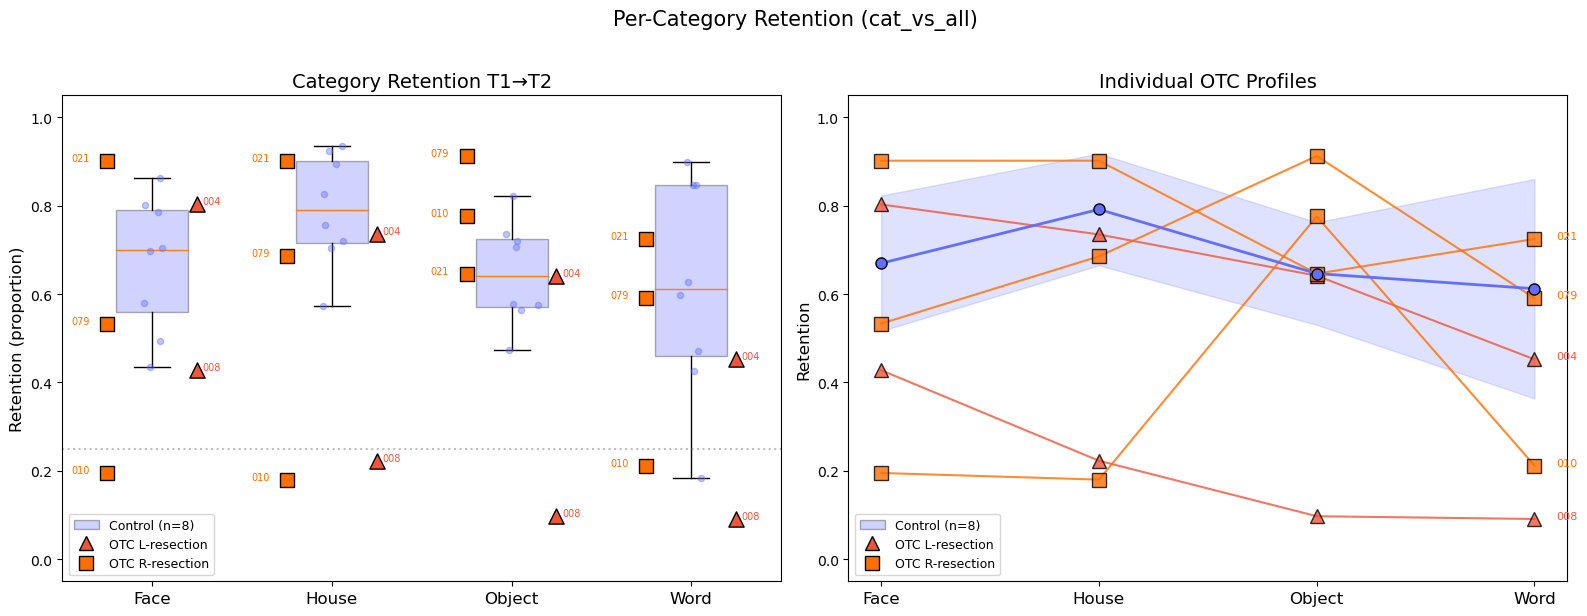

In [31]:
# ── Per-category retention: OTC vs Controls ──────────────────────────────────

from scipy.stats import t as t_dist, ttest_rel

def bootstrap_ci(data, n_boot=5000, ci=95):
    data = np.array(data)
    data = data[np.isfinite(data)]
    if len(data) < 2:
        return np.nanmean(data), np.nan, np.nan
    boot_means = np.array([np.mean(np.random.choice(data, size=len(data), replace=True)) 
                           for _ in range(n_boot)])
    lower = np.percentile(boot_means, (100 - ci) / 2)
    upper = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return np.nanmean(data), lower, upper

def crawford_t(patient_val, ctrl_vals):
    n = len(ctrl_vals)
    ctrl_mean = np.mean(ctrl_vals)
    ctrl_std = np.std(ctrl_vals, ddof=1)
    if ctrl_std == 0:
        return np.nan, np.nan
    t = (patient_val - ctrl_mean) / (ctrl_std * np.sqrt((n + 1) / n))
    p = 2 * t_dist.sf(abs(t), df=n - 1)
    return t, p

def permutation_test(group1, group2, n_perm=10000):
    group1 = np.array(group1)[np.isfinite(group1)]
    group2 = np.array(group2)[np.isfinite(group2)]
    observed_diff = np.mean(group1) - np.mean(group2)
    combined = np.concatenate([group1, group2])
    n1 = len(group1)
    count = 0
    for _ in range(n_perm):
        np.random.shuffle(combined)
        perm_diff = np.mean(combined[:n1]) - np.mean(combined[n1:])
        if abs(perm_diff) >= abs(observed_diff):
            count += 1
    return observed_diff, count / n_perm

# Step 1: Build per-subject, per-category retention table
ret_rows = []

for sid, info in long_subs.items():
    group = info.get('group', info['patient_status'])
    surgery = info.get('surgery_side', 'na')
    hemi = info['hemi'] if info['patient_status'] != 'control' else None
    hemis = [hemi] if hemi else ['l', 'r']
    
    cat_rets_by_hemi = {cat: [] for cat in CATEGORIES}
    overall_rets = []
    cos_sims = []
    
    for h in hemis:
        if (sid, h) not in transition_results:
            continue
        
        res = transition_results[(sid, h)]
        tc = res['trans_counts']
        overall_rets.append(res['retention'])
        
        for i, cat in enumerate(CATEGORIES):
            row_total = tc[i, :].sum()
            if row_total > 0:
                cat_rets_by_hemi[cat].append(tc[i, i] / row_total)
        
        if (sid, h) in stability_results:
            cos_sims.append(stability_results[(sid, h)]['mean_cos'])
    
    if not overall_rets:
        continue
    
    row = {
        'sub': sid,
        'group': group,
        'surgery_side': surgery,
        'overall_retention': np.mean(overall_rets),
        'mean_cos_sim': np.mean(cos_sims) if cos_sims else np.nan,
    }
    for cat in CATEGORIES:
        row[f'{cat}_retention'] = np.mean(cat_rets_by_hemi[cat]) if cat_rets_by_hemi[cat] else np.nan
    
    ret_rows.append(row)

ret_subject = pd.DataFrame(ret_rows)
ctrl_ret = ret_subject[ret_subject['group'] == 'control']
otc_ret = ret_subject[ret_subject['group'] == 'OTC']
nonotc_ret = ret_subject[ret_subject['group'] == 'nonOTC']

# Step 2: Print per-subject values
print("=" * 70)
print("PER-CATEGORY RETENTION")
print("=" * 70)

print(f"\n{'Sub':>10} {'Group':>8} {'Face':>8} {'House':>8} {'Object':>8} {'Word':>8} {'Overall':>8}")
for _, row in ret_subject.sort_values(['group', 'sub']).iterrows():
    print(f"{row['sub']:>10} {row['group']:>8} "
          f"{row['face_retention']:>8.3f} {row['house_retention']:>8.3f} "
          f"{row['object_retention']:>8.3f} {row['word_retention']:>8.3f} "
          f"{row['overall_retention']:>8.3f}")

# Step 3: Group means with CIs per category
print("\n--- Group means [95% CI] ---")
for cat in CATEGORIES + ['overall']:
    col = f'{cat}_retention' if cat != 'overall' else 'overall_retention'
    print(f"\n  {cat.upper()}:")
    for label, gdf in [('Control', ctrl_ret), ('OTC', otc_ret), ('nonOTC', nonotc_ret)]:
        vals = gdf[col].dropna().values
        if len(vals) == 0:
            continue
        m, lo, hi = bootstrap_ci(vals)
        print(f"    {label:>8} (n={len(vals)}): {m:.3f}  [{lo:.3f}, {hi:.3f}]")

# Step 4: Permutation tests — OTC vs Control per category
print("\n" + "=" * 70)
print("PERMUTATION TESTS: OTC vs Control per category")
print("=" * 70)

for cat in CATEGORIES + ['overall']:
    col = f'{cat}_retention' if cat != 'overall' else 'overall_retention'
    ctrl_vals = ctrl_ret[col].dropna().values
    otc_vals = otc_ret[col].dropna().values
    if len(ctrl_vals) < 2 or len(otc_vals) < 2:
        continue
    diff, p = permutation_test(otc_vals, ctrl_vals)
    sig = ' *' if p < .05 else ''
    print(f"  {cat:>10}: OTC-Ctrl = {diff:+.3f}, p = {p:.4f}{sig}")

# Step 5: Crawford's t — each OTC patient vs Controls, per category
print("\n" + "=" * 70)
print("CRAWFORD'S t: each OTC patient vs Controls")
print("=" * 70)

for _, row in otc_ret.iterrows():
    sub = row['sub']
    surgery = row['surgery_side']
    print(f"\n  {sub} ({surgery}-resection):")
    for cat in CATEGORIES + ['overall']:
        col = f'{cat}_retention' if cat != 'overall' else 'overall_retention'
        pt_val = row[col]
        ctrl_vals = ctrl_ret[col].dropna().values
        if not np.isfinite(pt_val) or len(ctrl_vals) < 2:
            continue
        t_val, p_val = crawford_t(pt_val, ctrl_vals)
        sig = ' *' if p_val < .05 else ''
        print(f"    {cat:>10}: val={pt_val:.3f}, t={t_val:+.2f}, p={p_val:.4f}{sig}")

# Step 6: Visualization — individual patients over control distribution
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Per-category retention — patients over control boxplot
ax = axes[0]
x = np.arange(len(CATEGORIES))

ctrl_data = [ctrl_ret[f'{cat}_retention'].dropna().values for cat in CATEGORIES]
bp = ax.boxplot(ctrl_data, positions=x, widths=0.4, patch_artist=True,
                showfliers=False, zorder=1)
for patch in bp['boxes']:
    patch.set_facecolor('#636EFA')
    patch.set_alpha(0.3)

for i, cat in enumerate(CATEGORIES):
    vals = ctrl_ret[f'{cat}_retention'].dropna().values
    jitter = np.random.normal(0, 0.04, size=len(vals))
    ax.scatter(x[i] + jitter, vals, color='#636EFA', alpha=0.4, s=20, zorder=2)

# OTC L-resection (intact LH) — triangles
otc_L = otc_ret[otc_ret['surgery_side'] == 'right']
for _, row in otc_L.iterrows():
    for i, cat in enumerate(CATEGORIES):
        val = row[f'{cat}_retention']
        if np.isfinite(val):
            ax.scatter(x[i] + 0.25, val, marker='^', s=120,
                      color='#EF553B', edgecolor='black', linewidth=1, zorder=3)
            ax.annotate(row['sub'].replace('sub-', ''), (x[i] + 0.28, val),
                       fontsize=7, color='#EF553B')

# OTC R-resection (intact RH) — squares
otc_R = otc_ret[otc_ret['surgery_side'] == 'left']
for _, row in otc_R.iterrows():
    for i, cat in enumerate(CATEGORIES):
        val = row[f'{cat}_retention']
        if np.isfinite(val):
            ax.scatter(x[i] - 0.25, val, marker='s', s=100,
                      color='#FF6F00', edgecolor='black', linewidth=1, zorder=3)
            ax.annotate(row['sub'].replace('sub-', ''), (x[i] - 0.45, val),
                       fontsize=7, color='#FF6F00')

ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in CATEGORIES], fontsize=12)
ax.set_ylabel('Retention (proportion)', fontsize=12)
ax.set_ylim(-0.05, 1.05)
ax.set_title('Category Retention T1→T2', fontsize=14)
ax.axhline(y=0.25, color='gray', linestyle=':', alpha=0.5)

legend_elements = [
    Patch(facecolor='#636EFA', alpha=0.3, edgecolor='black', label=f'Control (n={len(ctrl_ret)})'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='#EF553B',
           markeredgecolor='black', markersize=10, label='OTC L-resection'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#FF6F00',
           markeredgecolor='black', markersize=10, label='OTC R-resection'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='lower left')

# Panel 2: Per-patient profile across categories (line plot)
ax = axes[1]
for _, row in otc_L.iterrows():
    vals = [row[f'{cat}_retention'] for cat in CATEGORIES]
    ax.plot(x, vals, '^-', color='#EF553B', markersize=10, markeredgecolor='black',
            linewidth=1.5, alpha=0.8)
    ax.annotate(row['sub'].replace('sub-', ''), (x[-1] + 0.1, vals[-1]),
               fontsize=8, color='#EF553B')

for _, row in otc_R.iterrows():
    vals = [row[f'{cat}_retention'] for cat in CATEGORIES]
    ax.plot(x, vals, 's-', color='#FF6F00', markersize=10, markeredgecolor='black',
            linewidth=1.5, alpha=0.8)
    ax.annotate(row['sub'].replace('sub-', ''), (x[-1] + 0.1, vals[-1]),
               fontsize=8, color='#FF6F00')

# Control mean ± SD band
ctrl_means = [ctrl_ret[f'{cat}_retention'].mean() for cat in CATEGORIES]
ctrl_sds = [ctrl_ret[f'{cat}_retention'].std() for cat in CATEGORIES]
ax.fill_between(x, [m - s for m, s in zip(ctrl_means, ctrl_sds)],
                [m + s for m, s in zip(ctrl_means, ctrl_sds)],
                color='#636EFA', alpha=0.2)
ax.plot(x, ctrl_means, 'o-', color='#636EFA', markersize=8,
        markeredgecolor='black', linewidth=2, label='Ctrl mean ± SD')

ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in CATEGORIES], fontsize=12)
ax.set_ylabel('Retention', fontsize=12)
ax.set_ylim(-0.05, 1.05)
ax.set_title('Individual OTC Profiles', fontsize=14)
ax.legend(handles=legend_elements, fontsize=9, loc='lower left')

plt.suptitle(f'Per-Category Retention ({ALLEGIANCE_COPE_SET})', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'group_results',
            f'per_category_retention_{ALLEGIANCE_COPE_SET}.png'), dpi=150, bbox_inches='tight')
plt.show()

In [32]:
for (sid, h), res in sorted(transition_results.items()):
    if 'OTC' not in str(res.get('group', res.get('info', {}).get('group', ''))):
        # Try patient_status
        if res['group'] not in ['OTC', 'patient']:
            continue
    
    surgery = res.get('surgery_side', '?')
    tp = res['trans_pct']
    print(f"\n{sid} ({h}H, {surgery}-resection), retention={res['retention']:.3f}")
    print(f"{'':>8} {'→Face':>8} {'→House':>8} {'→Obj':>8} {'→Word':>8}")
    for i, cat in enumerate(CATEGORIES):
        print(f"{cat:>8} {tp[i,0]:>7.1f}% {tp[i,1]:>7.1f}% {tp[i,2]:>7.1f}% {tp[i,3]:>7.1f}%")


sub-004 (lH, right-resection), retention=0.687
            →Face   →House     →Obj    →Word
    face    80.3%     8.2%     5.9%     5.7%
   house     2.0%    73.5%    12.5%    12.1%
  object    11.5%    19.3%    64.2%     5.0%
    word    12.7%     8.7%    33.3%    45.2%

sub-007 (lH, left-resection), retention=0.731
            →Face   →House     →Obj    →Word
    face    63.3%     3.9%    16.0%    16.7%
   house    11.4%    74.5%    12.6%     1.5%
  object     6.0%     3.3%    82.5%     8.3%
    word    17.3%     1.5%    28.4%    52.8%

sub-007 (rH, left-resection), retention=0.750
            →Face   →House     →Obj    →Word
    face    69.0%     9.9%    20.4%     0.6%
   house     8.6%    81.2%    10.0%     0.2%
  object     5.6%    17.9%    76.3%     0.2%
    word    30.6%    12.2%    28.6%    28.6%

sub-008 (lH, right-resection), retention=0.301
            →Face   →House     →Obj    →Word
    face    42.8%    30.0%    20.2%     7.0%
   house    48.0%    22.3%    27.1%     2.6%


In [33]:
# ── Control word→object rate ─────────────────────────────────────────────────

for (sid, h), res in sorted(transition_results.items()):
    if res['group'] == 'control':
        tp = res['trans_pct']
        print(f"{sid} ({h}H): word→obj = {tp[3,2]:.1f}%, word retention = {tp[3,3]:.1f}%")

sub-018 (lH): word→obj = 9.8%, word retention = 70.4%
sub-018 (rH): word→obj = 4.2%, word retention = 23.7%
sub-022 (lH): word→obj = 54.5%, word retention = 25.5%
sub-022 (rH): word→obj = 51.1%, word retention = 11.0%
sub-025 (lH): word→obj = 17.2%, word retention = 62.7%
sub-025 (rH): word→obj = 59.5%, word retention = 22.7%
sub-052 (lH): word→obj = 3.9%, word retention = 84.8%
sub-052 (rH): word→obj = 2.9%, word retention = 84.7%
sub-058 (lH): word→obj = 48.3%, word retention = 49.7%
sub-058 (rH): word→obj = 21.0%, word retention = 75.7%
sub-062 (lH): word→obj = 0.6%, word retention = 86.2%
sub-062 (rH): word→obj = 1.1%, word retention = 93.7%
sub-064 (lH): word→obj = 3.1%, word retention = 94.5%
sub-064 (rH): word→obj = 18.8%, word retention = 74.8%
sub-068 (lH): word→obj = 27.7%, word retention = 43.4%
sub-068 (rH): word→obj = 4.7%, word retention = 76.3%


In [35]:
# ── Smoothed WTA: average betas in local neighborhood then classify ──────────
from scipy.ndimage import uniform_filter

SMOOTH_SIZE = 3  # 3x3x3 voxel neighborhood = ~6mm at 2mm resolution

def compute_smoothed_wta(betas, mask, threshold=1.96, smooth_size=SMOOTH_SIZE):
    """
    Smooth each category's beta map within the mask, then do WTA.
    """
    brain_shape = mask.shape
    
    # Rebuild full volumes, smooth, then re-extract
    smoothed_betas = {}
    for cat in CATEGORIES:
        vol = np.zeros(brain_shape)
        vol[mask] = betas[cat]
        
        # Smooth the values
        smoothed_vol = uniform_filter(vol, size=smooth_size)
        
        # Also smooth the mask to normalize by number of contributing voxels
        mask_float = mask.astype(float)
        smoothed_mask = uniform_filter(mask_float, size=smooth_size)
        smoothed_mask[smoothed_mask == 0] = 1  # avoid division by zero
        
        # Normalize: divide by local mask density so edges aren't diluted
        normalized = smoothed_vol / smoothed_mask
        
        smoothed_betas[cat] = normalized[mask]
    
    # Now do WTA on smoothed values
    beta_matrix = np.column_stack([smoothed_betas[cat] for cat in CATEGORIES])
    max_vals = np.max(beta_matrix, axis=1)
    winners = np.argmax(beta_matrix, axis=1)
    sorted_betas = np.sort(beta_matrix, axis=1)
    margin = sorted_betas[:, -1] - sorted_betas[:, -2]
    
    if threshold > 0:
        winners[max_vals < threshold] = -1
    
    return winners, margin, max_vals


# ── Compute smoothed transitions for longitudinal subjects ───────────────────

smooth_transition_results = {}

for sid, info in long_subs.items():
    sessions = info['sessions']
    t1_ses, t2_ses = sessions[0], sessions[-1]
    actual_first = info['actual_first_ses']
    
    hemi = info['hemi'] if info['patient_status'] != 'control' else None
    hemis = [hemi] if hemi else ['l', 'r']
    
    for h in hemis:
        mask, affine = get_votc_mask(sid, actual_first, h)
        if mask is None:
            continue
        
        betas_t1 = load_category_betas(sid, t1_ses, actual_first, mask, cope_map)
        betas_t2 = load_category_betas(sid, t2_ses, actual_first, mask, cope_map)
        if betas_t1 is None or betas_t2 is None:
            continue
        
        winners_t1, _, _ = compute_smoothed_wta(betas_t1, mask)
        winners_t2, _, _ = compute_smoothed_wta(betas_t2, mask)
        
        trans, trans_pct, retention = compute_transition_matrix(winners_t1, winners_t2)
        
        smooth_transition_results[(sid, h)] = {
            'trans_pct': trans_pct,
            'retention': retention,
            'group': info['patient_status'],
            'surgery_side': info.get('surgery_side', 'na'),
        }

# ── Print smoothed transitions: OTC patients ─────────────────────────────────

print(f"Smoothing: {SMOOTH_SIZE}x{SMOOTH_SIZE}x{SMOOTH_SIZE} voxel neighborhood")
print()

for (sid, h), res in sorted(smooth_transition_results.items()):
    if res['group'] not in ['OTC', 'patient']:
        continue
    
    surgery = res.get('surgery_side', '?')
    tp = res['trans_pct']
    print(f"{sid} ({h}H, {surgery}-resection), retention={res['retention']:.3f}")
    print(f"{'':>8} {'→Face':>8} {'→House':>8} {'→Obj':>8} {'→Word':>8}")
    for i, cat in enumerate(CATEGORIES):
        print(f"{cat:>8} {tp[i,0]:>7.1f}% {tp[i,1]:>7.1f}% {tp[i,2]:>7.1f}% {tp[i,3]:>7.1f}%")
    print()

# ── Compare: control word→object rate with smoothing ─────────────────────────

print("--- Control word→object (smoothed) ---")
for (sid, h), res in sorted(smooth_transition_results.items()):
    if res['group'] == 'control':
        tp = res['trans_pct']
        print(f"{sid} ({h}H): word→obj = {tp[3,2]:.1f}%, word retention = {tp[3,3]:.1f}%")

Smoothing: 3x3x3 voxel neighborhood

sub-004 (lH, right-resection), retention=0.719
            →Face   →House     →Obj    →Word
    face    85.6%     8.0%     3.2%     3.3%
   house     1.2%    77.7%    10.1%    10.9%
  object    11.2%    18.4%    66.7%     3.7%
    word     2.9%     5.7%    37.1%    54.3%

sub-008 (lH, right-resection), retention=0.307
            →Face   →House     →Obj    →Word
    face    45.3%    31.0%    18.4%     5.3%
   house    51.9%    16.3%    31.2%     0.6%
  object    34.4%    49.9%     7.0%     8.7%
    word    39.3%    23.2%    30.5%     7.0%

sub-010 (rH, left-resection), retention=0.534
            →Face   →House     →Obj    →Word
    face    17.0%    21.3%    57.2%     4.5%
   house    18.4%    17.8%    55.1%     8.8%
  object     4.6%     8.9%    83.6%     2.9%
    word     0.6%    24.2%    50.5%    24.8%

sub-021 (rH, left-resection), retention=0.755
            →Face   →House     →Obj    →Word
    face    91.0%     2.8%     5.9%     0.3%
   house 

In [36]:
# ── Average transition matrices: controls LH, controls RH ───────────────────

for hemi, label in [('l', 'Control LH'), ('r', 'Control RH')]:
    matrices = []
    for (sid, h), res in smooth_transition_results.items():
        if res['group'] == 'control' and h == hemi:
            matrices.append(res['trans_pct'])
    
    if not matrices:
        continue
    
    avg = np.mean(matrices, axis=0)
    print(f"\n{label} (n={len(matrices)}):")
    print(f"{'':>8} {'→Face':>8} {'→House':>8} {'→Obj':>8} {'→Word':>8}")
    for i, cat in enumerate(CATEGORIES):
        print(f"{cat:>8} {avg[i,0]:>7.1f}% {avg[i,1]:>7.1f}% {avg[i,2]:>7.1f}% {avg[i,3]:>7.1f}%")


Control LH (n=8):
            →Face   →House     →Obj    →Word
    face    65.9%    10.6%    12.5%    11.0%
   house     2.0%    78.9%    10.3%     8.8%
  object     4.4%    15.9%    67.4%    12.4%
    word     4.5%     9.1%    20.8%    65.6%

Control RH (n=8):
            →Face   →House     →Obj    →Word
    face    72.3%    11.9%     8.8%     7.0%
   house     4.0%    82.7%     5.6%     7.7%
  object    10.3%    19.6%    64.0%     6.1%
    word     3.2%    15.3%    23.3%    58.2%


In [37]:
# ── Profile stability BY CATEGORY: which voxels are reorganizing most? ───────

for (sid, h), res in sorted(stability_results.items()):
    group = res.get('info', {}).get('group', res['group'])
    if group not in ['OTC', 'control']:
        continue
    
    # Get the T1 WTA assignments and cosine values
    if (sid, h) not in transition_results:
        continue
    
    winners_t1 = transition_results[(sid, h)]['winners_t1']
    cos_sims = res['cos_sims']
    
    cat_cos = {}
    for i, cat in enumerate(CATEGORIES):
        cat_mask = winners_t1 == i
        if cat_mask.sum() > 10:
            cat_cos[cat] = np.nanmean(cos_sims[cat_mask])
        else:
            cat_cos[cat] = np.nan
    
    print(f"{sid} ({h}H, {group}): " + 
          "  ".join(f"{cat}={cat_cos[cat]:.3f}" if np.isfinite(cat_cos.get(cat, np.nan)) 
                    else f"{cat}=n/a" for cat in CATEGORIES))

sub-004 (lH, OTC): face=0.602  house=0.521  object=0.629  word=0.513
sub-008 (lH, OTC): face=0.194  house=0.194  object=0.123  word=0.138
sub-010 (rH, OTC): face=0.109  house=0.037  object=0.277  word=-0.015
sub-018 (lH, control): face=0.376  house=0.715  object=0.640  word=0.618
sub-018 (rH, control): face=0.396  house=0.737  object=0.652  word=0.200
sub-021 (rH, OTC): face=0.894  house=0.854  object=0.619  word=0.800
sub-022 (lH, control): face=0.346  house=0.548  object=0.722  word=0.302
sub-022 (rH, control): face=0.600  house=0.546  object=0.691  word=0.182
sub-025 (lH, control): face=0.310  house=0.554  object=0.779  word=0.676
sub-025 (rH, control): face=0.576  house=0.622  object=0.703  word=0.445
sub-052 (lH, control): face=0.661  house=0.690  object=0.544  word=0.600
sub-052 (rH, control): face=0.633  house=0.700  object=0.626  word=0.417
sub-058 (lH, control): face=0.721  house=0.642  object=0.808  word=0.736
sub-058 (rH, control): face=0.663  house=0.682  object=0.733  word

In [38]:
# ── Crawford's t: per-category cosine similarity, hemisphere-matched ─────────

# Build control distributions per hemisphere per category
ctrl_cos = {'l': {cat: [] for cat in CATEGORIES}, 'r': {cat: [] for cat in CATEGORIES}}

for (sid, h), res in stability_results.items():
    group = res.get('info', {}).get('group', res['group'])
    if group != 'control':
        continue
    if (sid, h) not in transition_results:
        continue
    
    winners_t1 = transition_results[(sid, h)]['winners_t1']
    cos_sims = res['cos_sims']
    
    for i, cat in enumerate(CATEGORIES):
        cat_mask = winners_t1 == i
        if cat_mask.sum() > 10:
            ctrl_cos[h][cat].append(np.nanmean(cos_sims[cat_mask]))

print("Control distributions (hemisphere-matched):")
for h in ['l', 'r']:
    label = 'LH' if h == 'l' else 'RH'
    for cat in CATEGORIES:
        vals = ctrl_cos[h][cat]
        print(f"  {label} {cat}: M={np.mean(vals):.3f} SD={np.std(vals, ddof=1):.3f} (n={len(vals)})")
    print()

# Test each OTC patient against matched hemisphere
print("=" * 70)
print("CRAWFORD'S t: Per-category cosine similarity (hemisphere-matched)")
print("=" * 70)

for (sid, h), res in sorted(stability_results.items()):
    group = res.get('info', {}).get('group', res['group'])
    if group != 'OTC':
        continue
    if (sid, h) not in transition_results:
        continue
    
    surgery = res.get('info', {}).get('surgery_side', '?')
    winners_t1 = transition_results[(sid, h)]['winners_t1']
    cos_sims = res['cos_sims']
    
    hemi_label = 'LH' if h == 'l' else 'RH'
    print(f"\n{sid} ({hemi_label}, {surgery}-resection) vs Control {hemi_label}:")
    
    for i, cat in enumerate(CATEGORIES):
        cat_mask = winners_t1 == i
        if cat_mask.sum() <= 10:
            print(f"  {cat:>8}: too few voxels")
            continue
        
        pt_val = np.nanmean(cos_sims[cat_mask])
        ctrl_vals = np.array(ctrl_cos[h][cat])
        
        if len(ctrl_vals) < 2:
            continue
        
        t_val, p_val = crawford_t(pt_val, ctrl_vals)
        sig = ' *' if p_val < .05 else ''
        print(f"  {cat:>8}: pt={pt_val:.3f}, ctrl={np.mean(ctrl_vals):.3f}, "
              f"t={t_val:+.2f}, p={p_val:.4f}{sig}")

Control distributions (hemisphere-matched):
  LH face: M=0.504 SD=0.213 (n=8)
  LH house: M=0.632 SD=0.155 (n=8)
  LH object: M=0.687 SD=0.094 (n=8)
  LH word: M=0.609 SD=0.144 (n=8)

  RH face: M=0.592 SD=0.163 (n=8)
  RH house: M=0.651 SD=0.181 (n=8)
  RH object: M=0.673 SD=0.072 (n=8)
  RH word: M=0.462 SD=0.213 (n=8)

CRAWFORD'S t: Per-category cosine similarity (hemisphere-matched)

sub-004 (LH, right-resection) vs Control LH:
      face: pt=0.602, ctrl=0.504, t=+0.44, p=0.6755
     house: pt=0.521, ctrl=0.632, t=-0.67, p=0.5231
    object: pt=0.629, ctrl=0.687, t=-0.58, p=0.5815
      word: pt=0.513, ctrl=0.609, t=-0.63, p=0.5507

sub-008 (LH, right-resection) vs Control LH:
      face: pt=0.194, ctrl=0.504, t=-1.37, p=0.2125
     house: pt=0.194, ctrl=0.632, t=-2.66, p=0.0323 *
    object: pt=0.123, ctrl=0.687, t=-5.64, p=0.0008 *
      word: pt=0.138, ctrl=0.609, t=-3.09, p=0.0176 *

sub-010 (RH, left-resection) vs Control RH:
      face: pt=0.109, ctrl=0.592, t=-2.79, p=0.0270

In [39]:
# ── Relocating vs Resident cosine: Crawford's t ─────────────────────────────
#
# Relocating category = lateralized category that lost its preferred hemisphere
#   R-resection (intact LH): face is relocating (face prefers RH)
#   L-resection (intact RH): word is relocating (word prefers LH)
#
# Resident categories = the other three
#
# Compute: relocating_cosine - mean(resident_cosines)
# If crowding destabilizes residents, this should be POSITIVE in patients
# (relocating is spared, residents are disrupted)

# First build per-subject, per-category cosine values
all_cat_cos = {}

for (sid, h), res in stability_results.items():
    if (sid, h) not in transition_results:
        continue
    
    group = res.get('info', {}).get('group', res['group'])
    surgery = res.get('info', {}).get('surgery_side', 'na')
    winners_t1 = transition_results[(sid, h)]['winners_t1']
    cos_sims = res['cos_sims']
    
    cat_cos = {}
    for i, cat in enumerate(CATEGORIES):
        cat_mask = winners_t1 == i
        if cat_mask.sum() > 10:
            cat_cos[cat] = np.nanmean(cos_sims[cat_mask])
        else:
            cat_cos[cat] = np.nan
    
    all_cat_cos[(sid, h)] = {
        'cat_cos': cat_cos,
        'group': group,
        'surgery_side': surgery,
        'hemi': h,
    }

# Compute relocating - resident difference
# Controls get the same logic applied to their hemisphere:
#   Control LH: "relocating" = face (face prefers RH, so in LH it's the outsider)
#   Control RH: "relocating" = word (word prefers LH, so in RH it's the outsider)

reloc_diff_rows = []

for (sid, h), info in all_cat_cos.items():
    cat_cos = info['cat_cos']
    group = info['group']
    surgery = info['surgery_side']
    
    # Determine relocating category based on hemisphere
    if h == 'l':
        relocating = 'face'  # face prefers RH, so it's the "outsider" in LH
    else:
        relocating = 'word'  # word prefers LH, so it's the "outsider" in RH
    
    residents = [cat for cat in CATEGORIES if cat != relocating]
    
    reloc_val = cat_cos.get(relocating, np.nan)
    resident_vals = [cat_cos.get(cat, np.nan) for cat in residents]
    resident_mean = np.nanmean(resident_vals)
    
    if np.isfinite(reloc_val) and np.isfinite(resident_mean):
        diff = reloc_val - resident_mean
    else:
        diff = np.nan
    
    reloc_diff_rows.append({
        'sub': sid,
        'hemi': h,
        'group': group,
        'surgery_side': surgery,
        'relocating': relocating,
        'reloc_cosine': reloc_val,
        'resident_mean_cosine': resident_mean,
        'reloc_minus_resident': diff,
    })

reloc_df = pd.DataFrame(reloc_diff_rows)

# Print all values
print("=" * 70)
print("RELOCATING vs RESIDENT PROFILE STABILITY")
print("Relocating = lateralized category displaced from preferred hemisphere")
print("  LH: face (prefers RH)")
print("  RH: word (prefers LH)")
print("=" * 70)

print(f"\n{'Sub':>10} {'Hemi':>5} {'Group':>8} {'Reloc':>6} {'Reloc cos':>10} {'Resid cos':>10} {'Diff':>8}")
for _, row in reloc_df.sort_values(['group', 'sub', 'hemi']).iterrows():
    print(f"{row['sub']:>10} {row['hemi']:>5} {row['group']:>8} {row['relocating']:>6} "
          f"{row['reloc_cosine']:>10.3f} {row['resident_mean_cosine']:>10.3f} "
          f"{row['reloc_minus_resident']:>+8.3f}")

# Crawford's t: each OTC patient vs hemisphere-matched controls
print("\n" + "=" * 70)
print("CRAWFORD'S t: Relocating-Resident difference vs Controls")
print("=" * 70)

# Build control distributions per hemisphere
ctrl_diffs = {'l': [], 'r': []}
for _, row in reloc_df.iterrows():
    if row['group'] == 'control' and np.isfinite(row['reloc_minus_resident']):
        ctrl_diffs[row['hemi']].append(row['reloc_minus_resident'])

for h in ['l', 'r']:
    label = 'LH' if h == 'l' else 'RH'
    vals = ctrl_diffs[h]
    print(f"\nControl {label} (n={len(vals)}): M={np.mean(vals):+.3f} SD={np.std(vals, ddof=1):.3f}")

# Test each OTC patient
for _, row in reloc_df.sort_values('sub').iterrows():
    if row['group'] != 'OTC':
        continue
    if not np.isfinite(row['reloc_minus_resident']):
        continue
    
    h = row['hemi']
    ctrl_vals = np.array(ctrl_diffs[h])
    pt_val = row['reloc_minus_resident']
    t_val, p_val = crawford_t(pt_val, ctrl_vals)
    sig = ' *' if p_val < .05 else ''
    label = 'LH' if h == 'l' else 'RH'
    print(f"  {row['sub']} ({label}, reloc={row['relocating']}): "
          f"diff={pt_val:+.3f}, t={t_val:+.2f}, p={p_val:.4f}{sig}")

RELOCATING vs RESIDENT PROFILE STABILITY
Relocating = lateralized category displaced from preferred hemisphere
  LH: face (prefers RH)
  RH: word (prefers LH)

       Sub  Hemi    Group  Reloc  Reloc cos  Resid cos     Diff
   sub-004     l      OTC   face      0.602      0.555   +0.048
   sub-008     l      OTC   face      0.194      0.152   +0.042
   sub-010     r      OTC   word     -0.015      0.141   -0.156
   sub-021     r      OTC   word      0.800      0.789   +0.011
   sub-079     r      OTC   word      0.347      0.625   -0.278
   sub-018     l  control   face      0.376      0.658   -0.282
   sub-018     r  control   word      0.200      0.595   -0.395
   sub-022     l  control   face      0.346      0.524   -0.178
   sub-022     r  control   word      0.182      0.612   -0.430
   sub-025     l  control   face      0.310      0.670   -0.360
   sub-025     r  control   word      0.445      0.634   -0.188
   sub-052     l  control   face      0.661      0.611   +0.050
   sub-0

In [40]:
# ── Profile stability: THRESHOLDED, hemisphere-matched ───────────────────────

STABILITY_THRESHOLD = 1.96  # must pass this on at least one category at T1

def compute_thresholded_stability(betas_t1, betas_t2, threshold=STABILITY_THRESHOLD):
    """
    Cosine similarity only for voxels that are selective for at least 
    one category at T1 (max across categories > threshold).
    """
    mat_t1 = np.column_stack([betas_t1[cat] for cat in CATEGORIES])
    mat_t2 = np.column_stack([betas_t2[cat] for cat in CATEGORIES])
    
    # Only include voxels where at least one category passes threshold at T1
    max_t1 = np.max(mat_t1, axis=1)
    selective = max_t1 > threshold
    n_selective = selective.sum()
    n_total = len(max_t1)
    
    if n_selective == 0:
        return None, None, None, 0, n_total
    
    mat_t1_sel = mat_t1[selective]
    mat_t2_sel = mat_t2[selective]
    
    # Cosine similarity per voxel
    dot_products = np.sum(mat_t1_sel * mat_t2_sel, axis=1)
    norms_t1 = np.linalg.norm(mat_t1_sel, axis=1)
    norms_t2 = np.linalg.norm(mat_t2_sel, axis=1)
    
    denom = norms_t1 * norms_t2
    valid = denom > 0
    cos_sims = np.full(n_selective, np.nan)
    cos_sims[valid] = dot_products[valid] / denom[valid]
    
    return cos_sims, np.nanmean(cos_sims), np.nanmedian(cos_sims), n_selective, n_total


# ── Compute thresholded stability for all longitudinal subjects ──────────────

thresh_stability = {}

for sid, info in long_subs.items():
    sessions = info['sessions']
    t1_ses, t2_ses = sessions[0], sessions[-1]
    actual_first = info['actual_first_ses']
    
    hemi = info['hemi'] if info['patient_status'] != 'control' else None
    hemis = [hemi] if hemi else ['l', 'r']
    
    for h in hemis:
        mask, affine = get_votc_mask(sid, actual_first, h)
        if mask is None:
            continue
        
        betas_t1 = load_category_betas(sid, t1_ses, actual_first, mask, cope_map)
        betas_t2 = load_category_betas(sid, t2_ses, actual_first, mask, cope_map)
        if betas_t1 is None or betas_t2 is None:
            continue
        
        cos_sims, mean_cos, median_cos, n_sel, n_total = \
            compute_thresholded_stability(betas_t1, betas_t2)
        
        if cos_sims is None:
            continue
        
        # Also compute per-category stability (for category-specific tests)
        # Use T1 WTA to assign voxels to categories
        winners_t1, _, _ = compute_wta(betas_t1, STABILITY_THRESHOLD)
        
        cat_cos = {}
        for i, cat in enumerate(CATEGORIES):
            cat_mask_wta = winners_t1 == i
            # Intersect with selective mask
            max_t1 = np.max(np.column_stack([betas_t1[c] for c in CATEGORIES]), axis=1)
            selective = max_t1 > STABILITY_THRESHOLD
            combined = cat_mask_wta & selective
            if combined.sum() > 10:
                mat_t1_cat = np.column_stack([betas_t1[c] for c in CATEGORIES])[combined]
                mat_t2_cat = np.column_stack([betas_t2[c] for c in CATEGORIES])[combined]
                dot = np.sum(mat_t1_cat * mat_t2_cat, axis=1)
                n1 = np.linalg.norm(mat_t1_cat, axis=1)
                n2 = np.linalg.norm(mat_t2_cat, axis=1)
                d = n1 * n2
                v = d > 0
                cs = np.full(combined.sum(), np.nan)
                cs[v] = dot[v] / d[v]
                cat_cos[cat] = np.nanmean(cs)
            else:
                cat_cos[cat] = np.nan
        
        group = info.get('group', info['patient_status'])
        surgery = info.get('surgery_side', 'na')
        
        thresh_stability[(sid, h)] = {
            'cos_sims': cos_sims,
            'mean_cos': mean_cos,
            'median_cos': median_cos,
            'cat_cos': cat_cos,
            'n_selective': n_sel,
            'n_total': n_total,
            'pct_selective': n_sel / n_total * 100,
            'group': group,
            'surgery_side': surgery,
            'hemi': h,
        }

# ── Print comparison: thresholded vs unthresholded ───────────────────────────

print("=" * 70)
print(f"PROFILE STABILITY: THRESHOLDED (z > {STABILITY_THRESHOLD})")
print("Only voxels selective for at least one category at T1")
print("=" * 70)

print(f"\n{'Sub':>10} {'Hemi':>5} {'Group':>8} {'N sel':>7} {'% sel':>6} "
      f"{'Thresh cos':>10} {'Orig cos':>10}")
for (sid, h), res in sorted(thresh_stability.items()):
    orig = stability_results.get((sid, h), {}).get('mean_cos', np.nan)
    print(f"{sid:>10} {h:>5} {res['group']:>8} {res['n_selective']:>7} "
          f"{res['pct_selective']:>5.1f}% {res['mean_cos']:>10.3f} {orig:>10.3f}")

# ── Group means with CIs ────────────────────────────────────────────────────

print("\n--- Group means (overall cosine, thresholded) ---")
for group_label in ['control', 'OTC', 'nonOTC']:
    # Average across hemispheres per subject first
    sub_means = {}
    for (sid, h), res in thresh_stability.items():
        if res['group'] != group_label:
            continue
        if sid not in sub_means:
            sub_means[sid] = []
        sub_means[sid].append(res['mean_cos'])
    
    vals = [np.mean(v) for v in sub_means.values()]
    if len(vals) < 2:
        continue
    m, lo, hi = bootstrap_ci(vals)
    print(f"  {group_label:>8} (n={len(vals)}): {m:.3f}  [{lo:.3f}, {hi:.3f}]")

# ── Hemisphere-matched per-category Crawford's t ─────────────────────────────

print("\n" + "=" * 70)
print("CRAWFORD'S t: Per-category cosine (thresholded, hemisphere-matched)")
print("=" * 70)

# Build control distributions
ctrl_cos_thresh = {'l': {cat: [] for cat in CATEGORIES}, 
                   'r': {cat: [] for cat in CATEGORIES}}
ctrl_overall_thresh = {'l': [], 'r': []}

for (sid, h), res in thresh_stability.items():
    if res['group'] != 'control':
        continue
    ctrl_overall_thresh[h].append(res['mean_cos'])
    for cat in CATEGORIES:
        if np.isfinite(res['cat_cos'].get(cat, np.nan)):
            ctrl_cos_thresh[h][cat].append(res['cat_cos'][cat])

print("\nControl distributions:")
for h in ['l', 'r']:
    label = 'LH' if h == 'l' else 'RH'
    print(f"  {label} overall: M={np.mean(ctrl_overall_thresh[h]):.3f} "
          f"SD={np.std(ctrl_overall_thresh[h], ddof=1):.3f} (n={len(ctrl_overall_thresh[h])})")
    for cat in CATEGORIES:
        vals = ctrl_cos_thresh[h][cat]
        if vals:
            print(f"  {label} {cat}: M={np.mean(vals):.3f} SD={np.std(vals, ddof=1):.3f} (n={len(vals)})")

# Test each OTC patient
print("\nOTC patients:")
for (sid, h), res in sorted(thresh_stability.items()):
    if res['group'] != 'OTC':
        continue
    
    surgery = res['surgery_side']
    label = 'LH' if h == 'l' else 'RH'
    print(f"\n  {sid} ({label}, {surgery}-resection):")
    
    # Overall
    pt_val = res['mean_cos']
    ctrl_vals = np.array(ctrl_overall_thresh[h])
    t_val, p_val = crawford_t(pt_val, ctrl_vals)
    sig = ' *' if p_val < .05 else ''
    print(f"    {'overall':>8}: pt={pt_val:.3f}, ctrl={np.mean(ctrl_vals):.3f}, "
          f"t={t_val:+.2f}, p={p_val:.4f}{sig}")
    
    # Per category
    for cat in CATEGORIES:
        pt_val = res['cat_cos'].get(cat, np.nan)
        ctrl_vals = np.array(ctrl_cos_thresh[h][cat])
        if not np.isfinite(pt_val) or len(ctrl_vals) < 2:
            continue
        t_val, p_val = crawford_t(pt_val, ctrl_vals)
        sig = ' *' if p_val < .05 else ''
        print(f"    {cat:>8}: pt={pt_val:.3f}, ctrl={np.mean(ctrl_vals):.3f}, "
              f"t={t_val:+.2f}, p={p_val:.4f}{sig}")

PROFILE STABILITY: THRESHOLDED (z > 1.96)
Only voxels selective for at least one category at T1

       Sub  Hemi    Group   N sel  % sel Thresh cos   Orig cos
   sub-004     l      OTC   33309  32.1%      0.578      0.279
   sub-007     r   nonOTC   59920  49.6%      0.730      0.583
   sub-008     l      OTC   38861  48.8%      0.177      0.144
   sub-010     r      OTC   41899  36.3%      0.155      0.074
   sub-018     l  control   54058  58.8%      0.619      0.453
   sub-018     r  control   56171  61.8%      0.603      0.481
   sub-021     r      OTC   38151  47.8%      0.710      0.502
   sub-022     l  control   64050  62.1%      0.509      0.395
   sub-022     r  control   54613  53.8%      0.486      0.355
   sub-025     l  control   75017  65.5%      0.612      0.440
   sub-025     r  control   72769  64.3%      0.649      0.511
   sub-045     r   nonOTC   64747  71.5%      0.637      0.506
   sub-052     l  control   59339  54.7%      0.612      0.408
   sub-052     r  con

CATEGORY-SPECIFIC SEARCHMASK RETENTION (threshold z > 1.96)
Each category measured within its own anatomical searchmask

       Sub  Hemi    Group      face (n sel)    house (n sel)   object (n sel)     word (n sel)
   sub-004     l      OTC    0.953 (  576)   0.706 ( 5821)   0.659 ( 8858)   0.431 (   58)
   sub-007     r   nonOTC    0.594 ( 8209)   0.751 ( 9979)   0.807 ( 5134)   0.744 (   86)
   sub-008     l      OTC    0.367 ( 6103)   0.373 ( 7237)   0.134 ( 3186)   0.232 (   95)
   sub-010     r      OTC    0.295 (  529)   0.228 ( 5774)   0.552 (14742)   0.356 (  795)
   sub-018     l  control    0.568 ( 2137)   0.864 ( 8177)   0.424 (12259)   0.590 ( 2506)
   sub-018     r  control    0.591 ( 3691)   0.819 (11721)   0.514 (12081)   0.247 (  255)
   sub-021     r      OTC    0.955 ( 1941)   0.875 ( 2932)   0.635 (12388)   0.545 (   11)
   sub-022     l  control    0.564 (  907)   0.754 ( 7321)   0.854 ( 7631)   0.378 ( 2474)
   sub-022     r  control    0.605 ( 1979)   0.852 ( 850

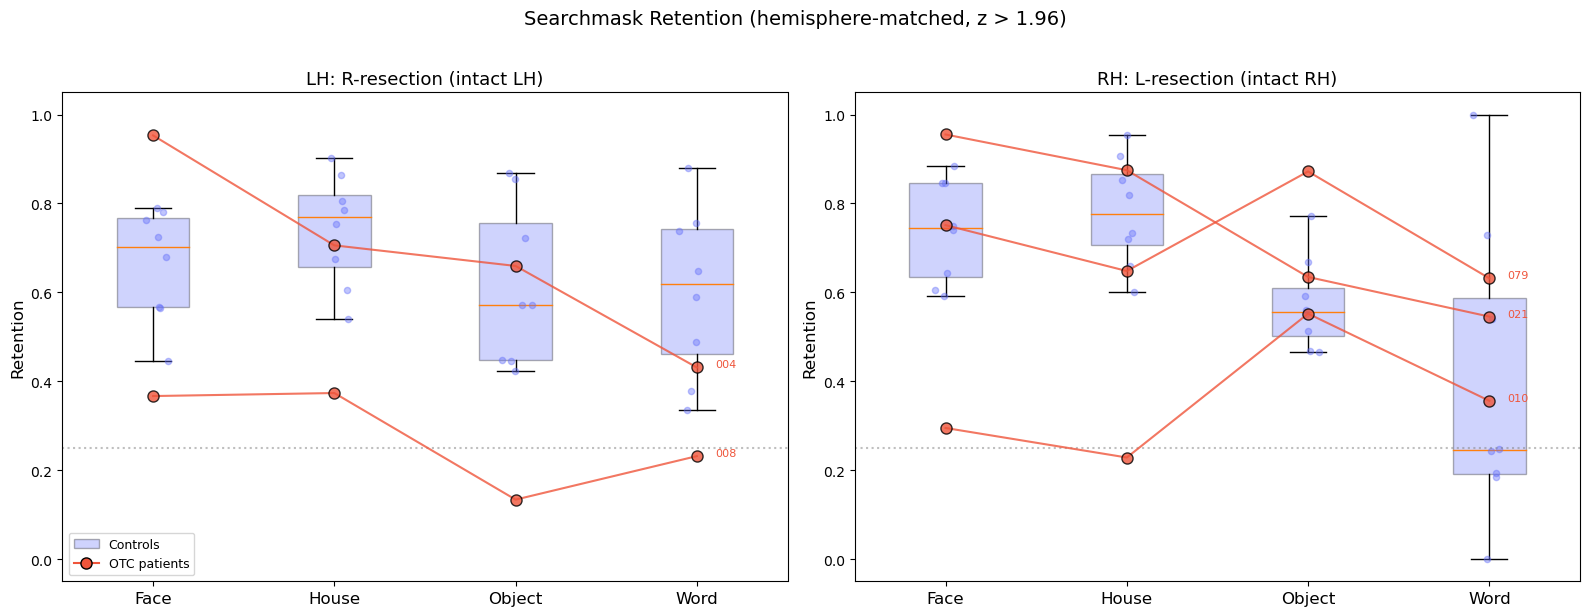

In [41]:
# ── Retention: category-specific searchmasks, hemisphere-matched ─────────────
#
# For each category, compute retention ONLY within that category's anatomical
# searchmask. This prevents e.g. counting "face" voxels in parahippocampal gyrus.
#
# Compare OTC patients to hemisphere-matched controls:
#   OTC R-resection (intact LH) → Control LH
#   OTC L-resection (intact RH) → Control RH

RETENTION_THRESHOLD = 1.96

def load_category_specific_retention(sid, t1_ses, t2_ses, actual_first, hemi, cope_map):
    """
    For each category, load its specific searchmask, compute WTA within 
    that mask at T1 and T2, and return retention for that category.
    """
    roi_dir = os.path.join(processed_dir, sid, f'ses-{actual_first}', 'ROIs')
    feat_t1 = os.path.join(processed_dir, sid, f'ses-{t1_ses}',
                           'derivatives', 'fsl', 'loc', 'HighLevel.gfeat')
    feat_t2 = os.path.join(processed_dir, sid, f'ses-{t2_ses}',
                           'derivatives', 'fsl', 'loc', 'HighLevel.gfeat')
    
    results = {}
    
    for cat_idx, cat in enumerate(CATEGORIES):
        # Load this category's searchmask
        mask_path = os.path.join(roi_dir, f'{hemi}_{cat}_searchmask.nii.gz')
        if not os.path.exists(mask_path):
            results[cat] = {'retention': np.nan, 'n_selective_t1': 0, 'n_total': 0}
            continue
        
        mask_img = nib.load(mask_path)
        mask = mask_img.get_fdata() > 0
        n_total = int(mask.sum())
        
        if n_total == 0:
            results[cat] = {'retention': np.nan, 'n_selective_t1': 0, 'n_total': 0}
            continue
        
        # Load all 4 category zstats within THIS mask at T1 and T2
        stat_file_t1 = 'zstat1.nii.gz' if t1_ses == actual_first else f'zstat1_ses{actual_first}.nii.gz'
        stat_file_t2 = 'zstat1.nii.gz' if t2_ses == actual_first else f'zstat1_ses{actual_first}.nii.gz'
        
        betas_t1 = {}
        betas_t2 = {}
        missing = False
        
        for c, cope_num in cope_map.items():
            path_t1 = os.path.join(feat_t1, f'cope{cope_num}.feat', 'stats', stat_file_t1)
            path_t2 = os.path.join(feat_t2, f'cope{cope_num}.feat', 'stats', stat_file_t2)
            
            if not os.path.exists(path_t1) or not os.path.exists(path_t2):
                missing = True
                break
            
            betas_t1[c] = nib.load(path_t1).get_fdata()[mask]
            betas_t2[c] = nib.load(path_t2).get_fdata()[mask]
        
        if missing:
            results[cat] = {'retention': np.nan, 'n_selective_t1': 0, 'n_total': n_total}
            continue
        
        # WTA at T1 and T2
        mat_t1 = np.column_stack([betas_t1[c] for c in CATEGORIES])
        mat_t2 = np.column_stack([betas_t2[c] for c in CATEGORIES])
        
        max_t1 = np.max(mat_t1, axis=1)
        max_t2 = np.max(mat_t2, axis=1)
        winners_t1 = np.argmax(mat_t1, axis=1)
        winners_t2 = np.argmax(mat_t2, axis=1)
        
        # Threshold: must be selective at T1
        selective_t1 = max_t1 > RETENTION_THRESHOLD
        
        # Within this category's mask, how many voxels prefer THIS category at T1?
        is_this_cat_t1 = (winners_t1 == cat_idx) & selective_t1
        n_selective_t1 = int(is_this_cat_t1.sum())
        
        if n_selective_t1 == 0:
            results[cat] = {'retention': np.nan, 'n_selective_t1': 0, 'n_total': n_total}
            continue
        
        # Of those, how many still prefer this category at T2?
        still_this_cat_t2 = (winners_t2[is_this_cat_t1] == cat_idx)
        retention = still_this_cat_t2.sum() / n_selective_t1
        
        # Also compute: what did the switchers become?
        switchers_t2 = winners_t2[is_this_cat_t1]
        transitions = {}
        for i, c in enumerate(CATEGORIES):
            transitions[c] = int((switchers_t2 == i).sum())
        
        results[cat] = {
            'retention': retention,
            'n_selective_t1': n_selective_t1,
            'n_total': n_total,
            'pct_selective': n_selective_t1 / n_total * 100,
            'transitions': transitions,
        }
    
    return results


# ── Compute for all longitudinal subjects ────────────────────────────────────

searchmask_retention = {}

for sid, info in long_subs.items():
    sessions = info['sessions']
    t1_ses, t2_ses = sessions[0], sessions[-1]
    actual_first = info['actual_first_ses']
    group = info.get('group', info['patient_status'])
    surgery = info.get('surgery_side', 'na')
    
    hemi = info['hemi'] if info['patient_status'] != 'control' else None
    hemis = [hemi] if hemi else ['l', 'r']
    
    for h in hemis:
        results = load_category_specific_retention(
            sid, t1_ses, t2_ses, actual_first, h, CAT_VS_ALL_COPES)
        
        searchmask_retention[(sid, h)] = {
            'results': results,
            'group': group,
            'surgery_side': surgery,
            'hemi': h,
        }

# ── Print per-subject results ────────────────────────────────────────────────

print("=" * 80)
print(f"CATEGORY-SPECIFIC SEARCHMASK RETENTION (threshold z > {RETENTION_THRESHOLD})")
print("Each category measured within its own anatomical searchmask")
print("=" * 80)

print(f"\n{'Sub':>10} {'Hemi':>5} {'Group':>8} ", end="")
for cat in CATEGORIES:
    print(f"{'':>3}{cat:>6} (n sel)", end="")
print()

for (sid, h), entry in sorted(searchmask_retention.items()):
    res = entry['results']
    print(f"{sid:>10} {h:>5} {entry['group']:>8} ", end="")
    for cat in CATEGORIES:
        r = res[cat]
        if np.isfinite(r['retention']):
            print(f"   {r['retention']:>5.3f} ({r['n_selective_t1']:>5})", end="")
        else:
            print(f"      n/a (    0)", end="")
    print()

# ── Build hemisphere-matched control distributions ───────────────────────────

ctrl_searchmask_ret = {'l': {cat: [] for cat in CATEGORIES},
                       'r': {cat: [] for cat in CATEGORIES}}

for (sid, h), entry in searchmask_retention.items():
    if entry['group'] != 'control':
        continue
    for cat in CATEGORIES:
        r = entry['results'][cat]
        if np.isfinite(r['retention']):
            ctrl_searchmask_ret[h][cat].append(r['retention'])

print("\n--- Control distributions (hemisphere-matched) ---")
for h in ['l', 'r']:
    label = 'LH' if h == 'l' else 'RH'
    for cat in CATEGORIES:
        vals = ctrl_searchmask_ret[h][cat]
        if vals:
            print(f"  {label} {cat:>8}: M={np.mean(vals):.3f} SD={np.std(vals, ddof=1):.3f} (n={len(vals)})")

# ── Crawford's t: each OTC patient vs hemisphere-matched controls ────────────

print("\n" + "=" * 80)
print("CRAWFORD'S t: Searchmask retention, hemisphere-matched")
print("=" * 80)

for (sid, h), entry in sorted(searchmask_retention.items()):
    if entry['group'] != 'OTC':
        continue
    
    surgery = entry['surgery_side']
    label = 'LH' if h == 'l' else 'RH'
    print(f"\n  {sid} ({label}, {surgery}-resection):")
    
    for cat in CATEGORIES:
        pt_val = entry['results'][cat]['retention']
        n_sel = entry['results'][cat]['n_selective_t1']
        ctrl_vals = np.array(ctrl_searchmask_ret[h][cat])
        
        if not np.isfinite(pt_val) or len(ctrl_vals) < 2:
            print(f"    {cat:>8}: n/a")
            continue
        
        t_val, p_val = crawford_t(pt_val, ctrl_vals)
        sig = ' *' if p_val < .05 else ''
        print(f"    {cat:>8}: pt={pt_val:.3f} (n={n_sel}), ctrl={np.mean(ctrl_vals):.3f}, "
              f"t={t_val:+.2f}, p={p_val:.4f}{sig}")

# ── Visualization: patients over control boxplots, hemisphere-matched ────────

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
from matplotlib.lines import Line2D

for ax, (hemi, hemi_label, resection_label) in zip(axes, [
    ('l', 'LH', 'R-resection (intact LH)'),
    ('r', 'RH', 'L-resection (intact RH)')
]):
    x = np.arange(len(CATEGORIES))
    
    # Control boxplot
    ctrl_data = [ctrl_searchmask_ret[hemi][cat] for cat in CATEGORIES]
    bp = ax.boxplot(ctrl_data, positions=x, widths=0.4, patch_artist=True,
                    showfliers=False, zorder=1)
    for patch in bp['boxes']:
        patch.set_facecolor('#636EFA')
        patch.set_alpha(0.3)
    
    for i, cat in enumerate(CATEGORIES):
        vals = ctrl_searchmask_ret[hemi][cat]
        jitter = np.random.normal(0, 0.04, size=len(vals))
        ax.scatter(x[i] + jitter, vals, color='#636EFA', alpha=0.4, s=20, zorder=2)
    
    # OTC patients for this hemisphere
    for (sid, h), entry in sorted(searchmask_retention.items()):
        if entry['group'] != 'OTC' or h != hemi:
            continue
        
        vals = [entry['results'][cat]['retention'] for cat in CATEGORIES]
        ax.plot(x, vals, 'o-', color='#EF553B', markersize=8, markeredgecolor='black',
                linewidth=1.5, alpha=0.8, zorder=3)
        # Label at rightmost point
        last_valid = None
        for i in range(len(vals) - 1, -1, -1):
            if np.isfinite(vals[i]):
                last_valid = i
                break
        if last_valid is not None:
            ax.annotate(sid.replace('sub-', ''), (x[last_valid] + 0.1, vals[last_valid]),
                       fontsize=8, color='#EF553B')
    
    ax.set_xticks(x)
    ax.set_xticklabels([c.capitalize() for c in CATEGORIES], fontsize=12)
    ax.set_ylabel('Retention', fontsize=12)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title(f'{hemi_label}: {resection_label}', fontsize=13)
    ax.axhline(y=0.25, color='gray', linestyle=':', alpha=0.5)

legend_elements = [
    Patch(facecolor='#636EFA', alpha=0.3, edgecolor='black', label='Controls'),
    Line2D([0], [0], marker='o', color='#EF553B', markeredgecolor='black',
           markersize=8, label='OTC patients'),
]
axes[0].legend(handles=legend_elements, fontsize=9, loc='lower left')

plt.suptitle(f'Searchmask Retention (hemisphere-matched, z > {RETENTION_THRESHOLD})',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(processed_dir, 'group_results',
            f'searchmask_retention_hemimatched.png'), dpi=150, bbox_inches='tight')
plt.show()